# Comparação de Modelos de Forecasting

**Objetivo**: Consolidar e comparar os resultados dos modelos de previsão avaliados na dissertação  
**Base**: 29 séries econômicas brasileiras (108 meses, jan/2017–dez/2025)  
**Horizonte**: 3 meses (multi-step) | **Teste**: últimos 24 meses | **Validação**: Walk-forward  
**MAPE**: fórmula epsilon `|y-ŷ|/(y+1e-8)` — padronizada em todos os modelos  

---

### Modelos Avaliados (14 ativos)

| Categoria | Modelo | Tipo | Descrição | Status |
|-----------|--------|------|-----------|--------|
| **Baseline** | Naive (Random Walk) | Benchmark | ŷ_{t+h} = y_t (último valor observado) | Ativo |
| **Baseline** | Seasonal Naive | Benchmark | ŷ_{t+h} = y_{t+h-12} (mesmo mês do ano anterior) | Ativo |
| **Foundation Model** | Chronos | Zero-shot | Amazon, arquitetura T5 | Ativo |
| **Foundation Model** | Lag-Llama | Fine-tuned | Meta, arquitetura Llama com lags | Ativo |
| **Foundation Model** | TimesFM | Zero-shot | Google, 200M params | Ativo |
| **Machine Learning** | XGBoost | Supervisionado | Gradient Boosting com features de lag | Ativo |
| **Machine Learning** | RandomForest | Supervisionado | Random Forest com features de lag | Ativo |
| **Estatístico** | SARIMAX | Paramétrico | ARIMA sazonal, auto_arima/AIC | Ativo |
| **Estatístico** | ARIMA | Paramétrico | AutoARIMA (pmdarima) | Ativo |
| **Estatístico** | ETS | Paramétrico | Suavização Exponencial (Holt-Winters) | Ativo |
| **Estatístico** | Prophet | Aditivo | Facebook/Meta, decomposição trend+seasonality | Ativo |
| **Estatístico** | Theta | Paramétrico | Método Theta (benchmark M3 Competition) | Ativo |
| **Volatilidade** | ARCH | Paramétrico | Modelo ARCH (Engle, 1982) | Ativo |
| **Volatilidade** | GARCH | Paramétrico | Modelo GARCH (Bollerslev, 1986) | Ativo |

### Estrutura deste Notebook

In [26]:
# Bibliotecas utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Configuração visual padrão
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("="*70)
print("COMPARAÇÃO DE MODELOS DE FORECASTING")
print("="*70)
print(f"Data: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

COMPARAÇÃO DE MODELOS DE FORECASTING
Data: 2026-04-19 18:37:46


## 1. Carregar Resultados dos Modelos

In [27]:
# ──────────────────────────────────────────────────────────────────────
# Dicionário com arquivos de resultados dos modelos avaliados.
# Cada modelo gera um CSV padronizado com colunas:
#   Serie, MAE, RMSE, MAPE, N_Pontos, Classificacao
# Obs: Todos os CSVs já foram padronizados nas sessões anteriores.
# ──────────────────────────────────────────────────────────────────────
RESULT_FILES = {
    'Naive': 'resultados_naive.csv',
    'SeasonalNaive': 'resultados_snaive.csv',
    'ARIMA': 'resultados_arima.csv',
    'ARCH': 'resultados_arch.csv',
    'Chronos': 'resultados_chronos.csv',
    'ETS': 'resultados_ets.csv',
    'GARCH': 'resultados_garch.csv',
    'LagLlama': 'resultados_lagllama.csv',
    'Prophet': 'resultados_prophet.csv',
    'RandomForest': 'resultados_randomforest.csv',
    'SARIMAX': 'resultados_sarimax.csv',
    'Theta': 'resultados_theta.csv',
    'TimesFM': 'resultados_timesfm.csv',
    'XGBoost': 'resultados_xgboost.csv',
}

# Carregar todos os resultados disponíveis
all_results = []

print("Carregando arquivos de resultados...\n")

for model_name, filename in RESULT_FILES.items():
    filepath = filename
    if os.path.exists(filepath):
        df_model = pd.read_csv(filepath)
        df_model['Modelo'] = model_name
        all_results.append(df_model)
        print(f"   OK  {model_name:14} : {len(df_model)} series carregadas")
    else:
        print(f"   FALTA  {model_name:14} : arquivo nao encontrado ({filename})")

print(f"\nTotal: {len(all_results)} modelos carregados de {len(RESULT_FILES)} esperados")

Carregando arquivos de resultados...

   OK  Naive          : 29 series carregadas
   OK  SeasonalNaive  : 29 series carregadas
   OK  ARIMA          : 29 series carregadas
   OK  ARCH           : 29 series carregadas
   OK  Chronos        : 29 series carregadas
   OK  ETS            : 29 series carregadas
   OK  GARCH          : 29 series carregadas
   OK  LagLlama       : 29 series carregadas
   OK  Prophet        : 29 series carregadas
   OK  RandomForest   : 29 series carregadas
   OK  SARIMAX        : 29 series carregadas
   OK  Theta          : 29 series carregadas
   OK  TimesFM        : 29 series carregadas
   OK  XGBoost        : 29 series carregadas

Total: 14 modelos carregados de 14 esperados


In [28]:
# ──────────────────────────────────────────────────────────────────────
# Consolida todos os DataFrames individuais em um único.
# Remove série PIM (descontinuada) e IPCA_mensal (variável-alvo).
# ──────────────────────────────────────────────────────────────────────
df_all = pd.concat(all_results, ignore_index=True)

# Séries que não fazem mais parte da análise
SERIES_EXCLUIDAS = ['PIM', 'IPCA_mensal']
df_all = df_all[~df_all['Serie'].isin(SERIES_EXCLUIDAS)]

# Selecionar apenas as colunas de métricas para a comparação
cols_needed = ['Serie', 'Modelo', 'MAE', 'RMSE', 'MAPE']
df_consolidated = df_all[cols_needed].copy()

print(f"DataFrame Consolidado:")
print(f"   Shape: {df_consolidated.shape}")
print(f"   Modelos: {df_consolidated['Modelo'].nunique()}")
print(f"   Series: {df_consolidated['Serie'].nunique()}")

DataFrame Consolidado:
   Shape: (406, 5)
   Modelos: 14
   Series: 29


## 2. Resumo por Modelo

In [29]:
# ──────────────────────────────────────────────────────────────────────
# Resumo estatístico por modelo: média, mediana, desvio-padrão, min, max
# para cada métrica (MAE, RMSE, MAPE). Ordenado pelo MAPE médio.
# ──────────────────────────────────────────────────────────────────────
df_summary = df_consolidated.groupby('Modelo').agg({
    'MAE': ['mean', 'median', 'std'],
    'RMSE': ['mean', 'median', 'std'],
    'MAPE': ['mean', 'median', 'std', 'min', 'max']
}).round(4)

df_summary.columns = ['_'.join(col) for col in df_summary.columns]
df_summary = df_summary.sort_values('MAPE_mean')

print("="*70)
print("RESUMO POR MODELO (ordenado por MAPE medio)")
print("="*70)
print(df_summary[['MAPE_mean', 'MAPE_median', 'MAPE_std', 'MAE_mean', 'RMSE_mean']].to_string())

RESUMO POR MODELO (ordenado por MAPE medio)
               MAPE_mean  MAPE_median  MAPE_std      MAE_mean     RMSE_mean
Modelo                                                                     
Chronos           5.3917       3.6155    7.1534  3.079760e+06  3.796456e+06
ARIMA             5.4689       3.2018    8.6527  4.324279e+06  5.366245e+06
SARIMAX           5.4965       3.6911    8.1527  4.324307e+06  5.366285e+06
TimesFM           5.7168       3.3586    7.9857  6.745838e+06  8.316003e+06
GARCH             6.1214       4.0900    7.8202  2.166547e+06  3.009411e+06
ARCH              6.1824       4.0600    8.4118  2.158351e+06  3.001628e+06
ETS               6.2216       3.2218   10.0849  2.271822e+06  2.806324e+06
Theta             6.2559       3.4823    9.7061  5.931988e+06  6.598379e+06
Naive             6.2936       4.0878    8.5462  7.404870e+06  8.726392e+06
RandomForest      6.6889       4.8881    7.4861  1.669440e+07  1.757666e+07
XGBoost           7.9711       4.9211    9.6

In [30]:
# Ranking simples dos modelos ordenado pelo MAPE médio global
print("\nRANKING DE MODELOS (por MAPE medio)")
print("="*50)

ranking = df_consolidated.groupby('Modelo')['MAPE'].mean().sort_values()

for i, (modelo, mape) in enumerate(ranking.items(), 1):
    medal = "1o" if i == 1 else "2o" if i == 2 else "3o" if i == 3 else "  "
    print(f"{medal} {i:2}. {modelo:15} : {mape:.2f}%")


RANKING DE MODELOS (por MAPE medio)
1o  1. Chronos         : 5.39%
2o  2. ARIMA           : 5.47%
3o  3. SARIMAX         : 5.50%
    4. TimesFM         : 5.72%
    5. GARCH           : 6.12%
    6. ARCH            : 6.18%
    7. ETS             : 6.22%
    8. Theta           : 6.26%
    9. Naive           : 6.29%
   10. RandomForest    : 6.69%
   11. XGBoost         : 7.97%
   12. LagLlama        : 10.75%
   13. Prophet         : 12.15%
   14. SeasonalNaive   : 12.41%


## 3. Melhor Modelo por Série

In [31]:
# ──────────────────────────────────────────────────────────────────────
# Para cada série temporal, identifica qual modelo obteve o menor MAPE.
# Isso mostra que nenhum modelo domina todas as séries.
# ──────────────────────────────────────────────────────────────────────
idx_best = df_consolidated.groupby('Serie')['MAPE'].idxmin()
df_best = df_consolidated.loc[idx_best][['Serie', 'Modelo', 'MAPE']].sort_values('MAPE')

print("MELHOR MODELO PARA CADA SERIE")
print("="*50)

for i, (_, row) in enumerate(df_best.iterrows(), 1):
    print(f"{i:2}. {row['Serie']:25} -> {row['Modelo']:12} ({row['MAPE']:.2f}%)")

MELHOR MODELO PARA CADA SERIE
 1. CPI_USA                   -> SARIMAX      (0.16%)
 2. Credito_Total             -> ETS          (0.37%)
 3. Prod_Ind_USA              -> Naive        (0.44%)
 4. M2                        -> ARCH         (0.47%)
 5. Divida_PIB                -> ARIMA        (0.74%)
 6. Massa_Salarial            -> Prophet      (0.92%)
 7. NUCI_FGV                  -> Chronos      (1.20%)
 8. IBC_Br                    -> SARIMAX      (1.41%)
 9. PMS_Volume                -> ARIMA        (1.45%)
10. Vendas_Varejo             -> Chronos      (1.58%)
11. ICE_Empresarial           -> TimesFM      (1.73%)
12. Selic                     -> ARIMA        (1.93%)
13. Dollar_Index_Fed          -> RandomForest (1.98%)
14. SP500                     -> ARCH         (2.50%)
15. ICC_FGV                   -> Chronos      (2.86%)
16. Inadimplencia             -> ETS          (2.97%)
17. Cambio_USDBRL             -> TimesFM      (3.21%)
18. ETF_Emergentes            -> SARIMAX      (3.37%

In [32]:
# Contagem de vitórias: quantas séries cada modelo venceu (menor MAPE)
wins = df_best['Modelo'].value_counts()

print("\nCONTAGEM DE VITORIAS (melhor modelo por serie)")
print("="*50)

for modelo, count in wins.items():
    bar = "█" * count
    print(f"{modelo:15} : {count:2} vitorias {bar}")


CONTAGEM DE VITORIAS (melhor modelo por serie)
ARIMA           :  5 vitorias █████
Chronos         :  5 vitorias █████
SARIMAX         :  3 vitorias ███
ETS             :  3 vitorias ███
Naive           :  3 vitorias ███
TimesFM         :  3 vitorias ███
ARCH            :  2 vitorias ██
Prophet         :  2 vitorias ██
RandomForest    :  1 vitorias █
Theta           :  1 vitorias █
LagLlama        :  1 vitorias █


## 4. Visualizações

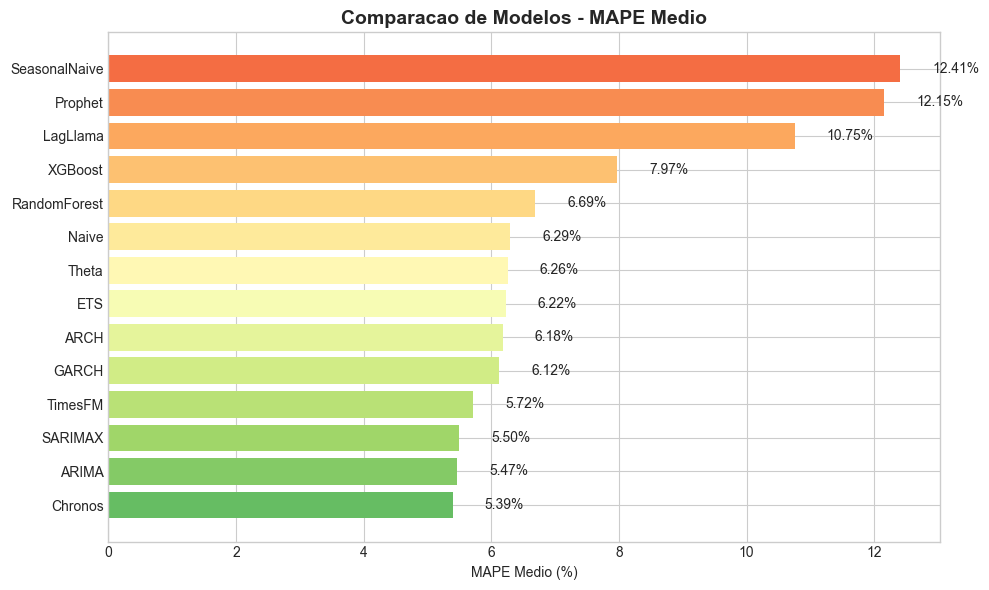

Grafico salvo: consolidado_mape_modelos.png


In [33]:
# Gráfico de barras horizontais - MAPE médio por modelo (ordenado)
fig, ax = plt.subplots(figsize=(10, 6))

ranking = df_consolidated.groupby('Modelo')['MAPE'].mean().sort_values()
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(ranking)))

bars = ax.barh(ranking.index, ranking.values, color=colors)
ax.set_xlabel('MAPE Medio (%)')
ax.set_title('Comparacao de Modelos - MAPE Medio', fontsize=14, fontweight='bold')

for bar, val in zip(bars, ranking.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', 
            va='center', fontsize=10)

plt.tight_layout()
plt.savefig('consolidado_mape_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo: consolidado_mape_modelos.png")

C:\Users\phill\AppData\Local\Temp\ipykernel_24956\1550810702.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_consolidated, x='Modelo', y='MAPE', order=order,


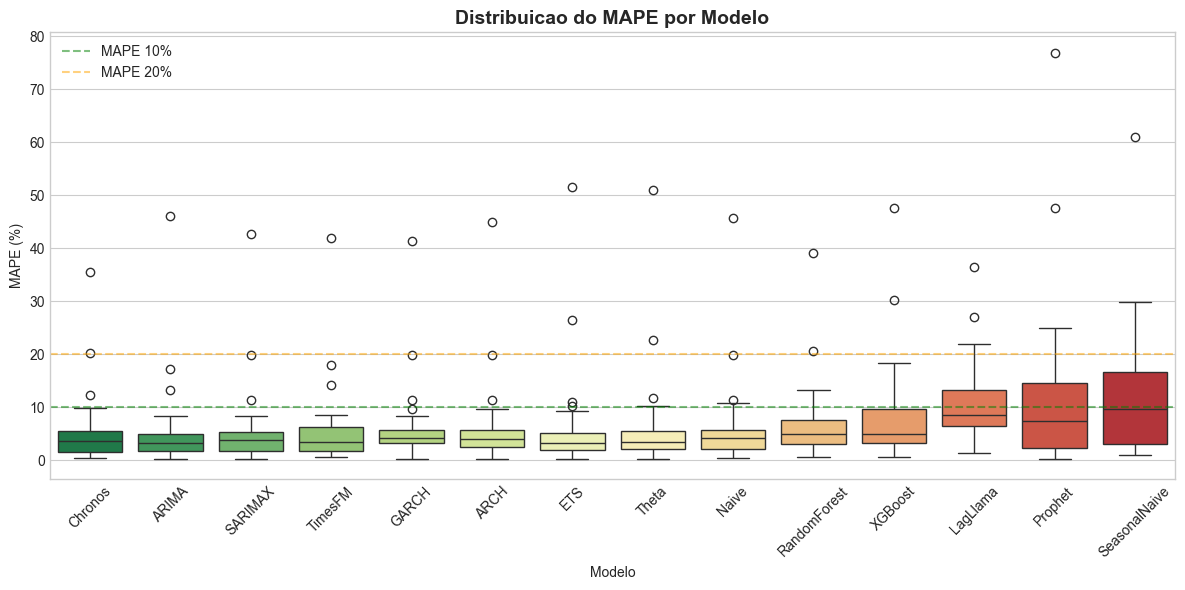

Grafico salvo: consolidado_boxplot_mape.png


In [34]:
# Boxplot: mostra a distribuição do MAPE por modelo (mediana, quartis, outliers).
# Linhas de referência em 10% e 20% ajudam a contextualizar a qualidade.
fig, ax = plt.subplots(figsize=(12, 6))

order = df_consolidated.groupby('Modelo')['MAPE'].mean().sort_values().index

sns.boxplot(data=df_consolidated, x='Modelo', y='MAPE', order=order, 
            palette='RdYlGn_r', ax=ax)

ax.set_ylabel('MAPE (%)')
ax.set_xlabel('Modelo')
ax.set_title('Distribuicao do MAPE por Modelo', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

ax.axhline(y=10, color='green', linestyle='--', alpha=0.5, label='MAPE 10%')
ax.axhline(y=20, color='orange', linestyle='--', alpha=0.5, label='MAPE 20%')
ax.legend()

plt.tight_layout()
plt.savefig('consolidado_boxplot_mape.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo: consolidado_boxplot_mape.png")

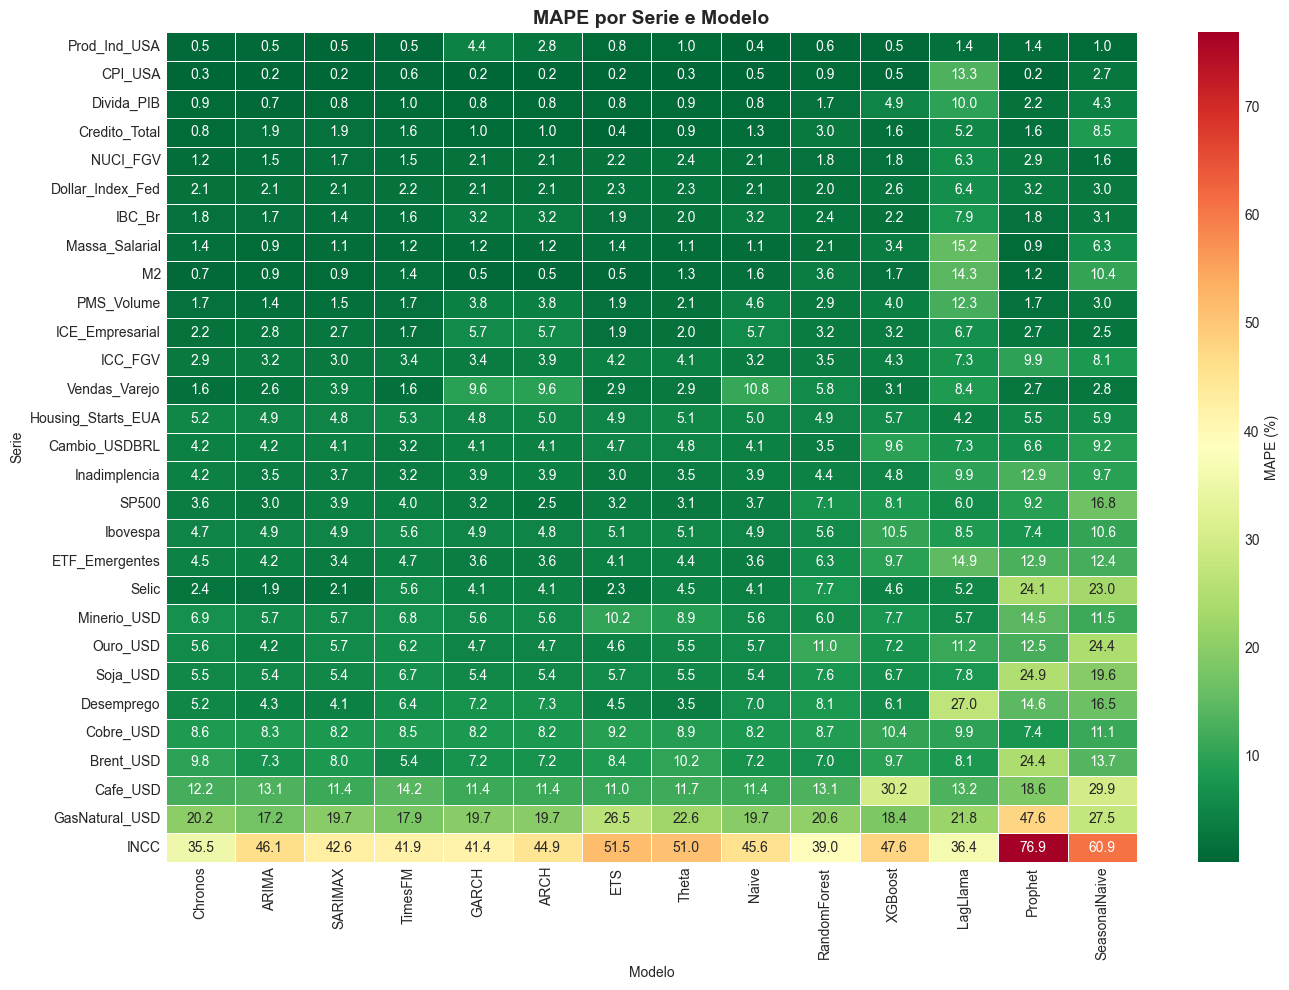

Grafico salvo: consolidado_heatmap_mape.png


In [35]:
# Heatmap: MAPE por Série x Modelo — permite visualizar quais séries
# são difíceis para todos os modelos e quais modelos se destacam em cada série.
pivot_mape = df_consolidated.pivot_table(values='MAPE', index='Serie', columns='Modelo')

# Ordenar séries e modelos pelo MAPE médio
pivot_mape = pivot_mape.loc[pivot_mape.mean(axis=1).sort_values().index]
pivot_mape = pivot_mape[pivot_mape.mean().sort_values().index]

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(pivot_mape, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'MAPE (%)'})

ax.set_title('MAPE por Serie e Modelo', fontsize=14, fontweight='bold')
ax.set_xlabel('Modelo')
ax.set_ylabel('Serie')

plt.tight_layout()
plt.savefig('consolidado_heatmap_mape.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo: consolidado_heatmap_mape.png")

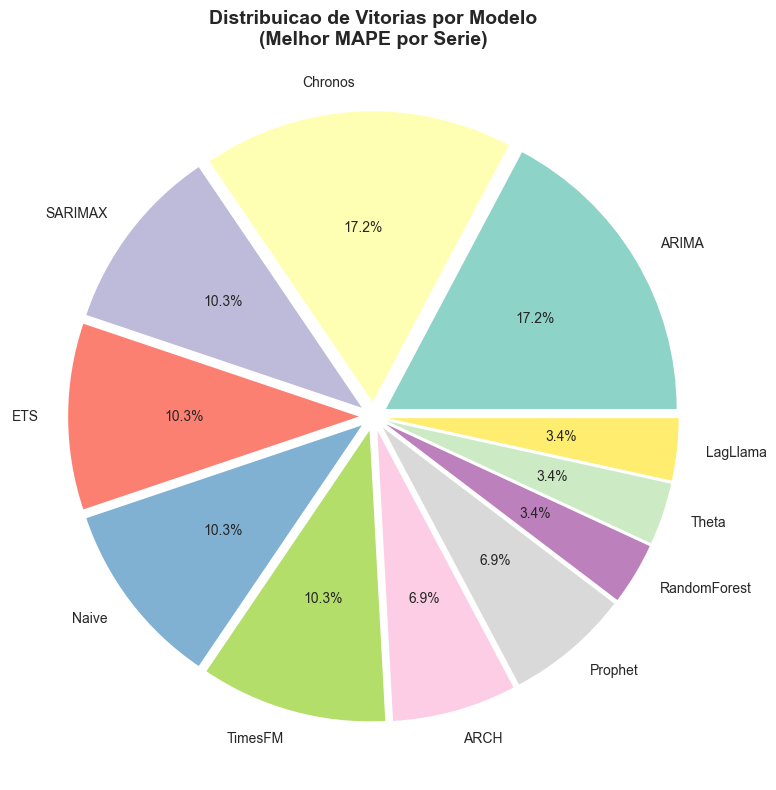

Grafico salvo: consolidado_pizza_vitorias.png


In [36]:
# Pizza: distribuição proporcional de vitórias entre os modelos
fig, ax = plt.subplots(figsize=(8, 8))

wins = df_best['Modelo'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(wins)))

wedges, texts, autotexts = ax.pie(wins.values, labels=wins.index, autopct='%1.1f%%',
                                   colors=colors, explode=[0.05]*len(wins))

ax.set_title('Distribuicao de Vitorias por Modelo\n(Melhor MAPE por Serie)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('consolidado_pizza_vitorias.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo: consolidado_pizza_vitorias.png")

## 5. Análise Detalhada por Série

In [37]:
# Tabela completa: MAPE de cada modelo em cada série (pivot table)
print("MAPE POR SERIE E MODELO")
print("="*70)

pivot_display = pivot_mape.round(2)
print(pivot_display.to_string())

MAPE POR SERIE E MODELO
Modelo              Chronos  ARIMA  SARIMAX  TimesFM  GARCH   ARCH    ETS  Theta  Naive  RandomForest  XGBoost  LagLlama  Prophet  SeasonalNaive
Serie                                                                                                                                           
Prod_Ind_USA           0.53   0.49     0.46     0.54   4.42   2.82   0.84   0.99   0.44          0.56     0.52      1.40     1.36           0.97
CPI_USA                0.34   0.17     0.16     0.58   0.17   0.18   0.23   0.25   0.45          0.93     0.50     13.31     0.23           2.75
Divida_PIB             0.87   0.74     0.78     1.02   0.80   0.81   0.80   0.87   0.81          1.70     4.92     10.01     2.20           4.35
Credito_Total          0.85   1.89     1.89     1.60   0.98   0.97   0.37   0.94   1.29          2.99     1.64      5.21     1.61           8.47
NUCI_FGV               1.20   1.48     1.68     1.50   2.11   2.11   2.20   2.39   2.11          1.75     

In [38]:
# ──────────────────────────────────────────────────────────────────────
# Classificação das séries por dificuldade de previsão,
# baseada no MAPE médio considerando todos os modelos.
# Faixas: Fácil (<5%), Moderada (5-15%), Difícil (>=15%)
# ──────────────────────────────────────────────────────────────────────
avg_mape_per_serie = df_consolidated.groupby('Serie')['MAPE'].mean().sort_values()

print("\nCLASSIFICACAO DE SERIES POR DIFICULDADE")
print("="*50)
print("(MAPE medio considerando todos os modelos)\n")

print("FACEIS (MAPE < 5%):")
for serie, mape in avg_mape_per_serie[avg_mape_per_serie < 5].items():
    print(f"   - {serie}: {mape:.2f}%")

print("\nMODERADAS (5% <= MAPE < 15%):")
for serie, mape in avg_mape_per_serie[(avg_mape_per_serie >= 5) & (avg_mape_per_serie < 15)].items():
    print(f"   - {serie}: {mape:.2f}%")

print("\nDIFICEIS (MAPE >= 15%):")
for serie, mape in avg_mape_per_serie[avg_mape_per_serie >= 15].items():
    print(f"   - {serie}: {mape:.2f}%")


CLASSIFICACAO DE SERIES POR DIFICULDADE
(MAPE medio considerando todos os modelos)

FACEIS (MAPE < 5%):
   - Prod_Ind_USA: 1.17%
   - CPI_USA: 1.45%
   - Divida_PIB: 2.19%
   - Credito_Total: 2.19%
   - NUCI_FGV: 2.22%
   - Dollar_Index_Fed: 2.63%
   - IBC_Br: 2.66%
   - Massa_Salarial: 2.76%
   - M2: 2.82%
   - PMS_Volume: 3.32%
   - ICE_Empresarial: 3.49%
   - ICC_FGV: 4.60%
   - Vendas_Varejo: 4.87%

MODERADAS (5% <= MAPE < 15%):
   - Housing_Starts_EUA: 5.09%
   - Cambio_USDBRL: 5.25%
   - Inadimplencia: 5.31%
   - SP500: 5.53%
   - Ibovespa: 6.25%
   - ETF_Emergentes: 6.58%
   - Selic: 6.84%
   - Minerio_USD: 7.62%
   - Ouro_USD: 8.09%
   - Soja_USD: 8.35%
   - Desemprego: 8.69%
   - Cobre_USD: 8.85%
   - Brent_USD: 9.55%

DIFICEIS (MAPE >= 15%):
   - Cafe_USD: 15.21%
   - GasNatural_USD: 22.80%
   - INCC: 47.23%


## 6. Teste de Significância Estatística (Friedman + Nemenyi)

O **Teste de Friedman** é um teste não-paramétrico para comparar múltiplos modelos avaliados nos mesmos conjuntos de dados (Demšar, 2006).  
Se significativo, aplica-se o **teste post-hoc de Nemenyi** para identificar quais pares de modelos diferem significativamente.

In [39]:
# ──────────────────────────────────────────────────────────────────────
# Teste de Friedman: teste não-paramétrico que verifica se existe
# diferença estatisticamente significativa entre os modelos quando
# avaliados nos mesmos conjuntos de dados (Demšar, 2006).
# H0: todos os modelos têm desempenho equivalente
# H1: ao menos um par de modelos difere significativamente
# ──────────────────────────────────────────────────────────────────────
from scipy.stats import friedmanchisquare, wilcoxon, rankdata

# Matriz de MAPE: séries (linhas) x modelos (colunas)
pivot_test = df_consolidated.pivot_table(values='MAPE', index='Serie', columns='Modelo')
pivot_test = pivot_test.dropna()  # Apenas séries com resultados para todos os modelos

print("="*70)
print("TESTE DE FRIEDMAN - Comparacao Global de Modelos")
print("="*70)
print(f"Series utilizadas: {len(pivot_test)} (com resultados para todos os modelos)")
print(f"Modelos comparados: {len(pivot_test.columns)}\n")

# Teste de Friedman
model_arrays = [pivot_test[col].values for col in pivot_test.columns]
stat, p_value = friedmanchisquare(*model_arrays)

print(f"Estatistica de Friedman (chi2): {stat:.4f}")
print(f"p-valor: {p_value:.6f}")
print(f"Significativo (alpha=0.05): {'SIM' if p_value < 0.05 else 'NAO'}")

if p_value < 0.05:
    print("\n-> Ha diferenca estatisticamente significativa entre os modelos.")
    print("  Prosseguindo com analise post-hoc (Nemenyi)...")
else:
    print("\n-> Nao ha evidencia de diferenca significativa entre os modelos.")

TESTE DE FRIEDMAN - Comparacao Global de Modelos
Series utilizadas: 29 (com resultados para todos os modelos)
Modelos comparados: 14

Estatistica de Friedman (chi2): 137.0225
p-valor: 0.000000
Significativo (alpha=0.05): SIM

-> Ha diferenca estatisticamente significativa entre os modelos.
  Prosseguindo com analise post-hoc (Nemenyi)...


In [40]:
# ──────────────────────────────────────────────────────────────────────
# Post-hoc de Nemenyi (Demšar, 2006):
# Após rejeitar H0 do Friedman, compara todos os pares de modelos.
# A Diferença Crítica (CD) determina se dois modelos diferem:
#   CD = q_alpha * sqrt(k*(k+1) / (6*N))
# onde k = nº modelos, N = nº séries, q_alpha = valor tabelado.
# ──────────────────────────────────────────────────────────────────────
from scipy.stats import norm
import itertools

k = len(pivot_test.columns)  # número de modelos
N = len(pivot_test)           # número de séries

# Calcular ranks médios por modelo (rank 1 = melhor = menor MAPE)
ranks = pivot_test.rank(axis=1)
mean_ranks = ranks.mean().sort_values()

# Diferença Crítica de Nemenyi
alpha = 0.05
# Valor crítico da distribuição studentized range (q_alpha) para k grupos
# Tabela de q_alpha para Nemenyi (Demšar, 2006) - valores aproximados
q_alpha_table = {
    2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 
    7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164, 11: 3.219,
    12: 3.268, 13: 3.313, 14: 3.354, 15: 3.391, 16: 3.426,
}
q_alpha = q_alpha_table.get(k, 3.426)

CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))

print("="*70)
print("ANALISE POST-HOC DE NEMENYI")
print("="*70)
print(f"\nDiferenca Critica (CD) para alpha={alpha}: {CD:.4f}")
print(f"q_alpha({k}) = {q_alpha}, N = {N}, k = {k}")

print(f"\nRANKING MEDIO DOS MODELOS:")
print("-"*40)
for i, (modelo, rank) in enumerate(mean_ranks.items(), 1):
    medal = "1o" if i == 1 else "2o" if i == 2 else "3o" if i == 3 else "  "
    print(f"{medal} {i:2}. {modelo:15} : {rank:.3f}")

# Comparações par-a-par
print(f"\nCOMPARACAES PAR-A-PAR (diferenca de ranks):")
print(f"   Pares com |diff| > CD ({CD:.3f}) sao significativamente diferentes\n")

modelos = mean_ranks.index.tolist()
pairwise_results = []

for i, j in itertools.combinations(range(len(modelos)), 2):
    m1, m2 = modelos[i], modelos[j]
    diff = abs(mean_ranks[m1] - mean_ranks[m2])
    sig = "* Sig." if diff > CD else "  n.s."
    pairwise_results.append({
        'Modelo_1': m1, 'Modelo_2': m2,
        'Rank_1': mean_ranks[m1], 'Rank_2': mean_ranks[m2],
        'Diff': diff, 'Significativo': diff > CD
    })
    print(f"   {m1:12} vs {m2:12} : delta_rank = {diff:.3f}  {sig}")

df_nemenyi = pd.DataFrame(pairwise_results)
print(f"\nTotal de pares comparados: {len(df_nemenyi)}")


ANALISE POST-HOC DE NEMENYI

Diferenca Critica (CD) para alpha=0.05: 3.6847
q_alpha(14) = 3.354, N = 29, k = 14

RANKING MEDIO DOS MODELOS:
----------------------------------------
1o  1. ARIMA           : 4.241
2o  2. SARIMAX         : 4.414
3o  3. Chronos         : 5.483
    4. GARCH           : 5.948
    5. ARCH            : 6.017
    6. ETS             : 6.414
    7. TimesFM         : 6.414
    8. Naive           : 6.448
    9. Theta           : 7.448
   10. RandomForest    : 8.414
   11. XGBoost         : 10.172
   12. Prophet         : 10.310
   13. LagLlama        : 11.448
   14. SeasonalNaive   : 11.828

COMPARACAES PAR-A-PAR (diferenca de ranks):
   Pares com |diff| > CD (3.685) sao significativamente diferentes

   ARIMA        vs SARIMAX      : delta_rank = 0.172    n.s.
   ARIMA        vs Chronos      : delta_rank = 1.241    n.s.
   ARIMA        vs GARCH        : delta_rank = 1.707    n.s.
   ARIMA        vs ARCH         : delta_rank = 1.776    n.s.
   ARIMA        vs ETS 

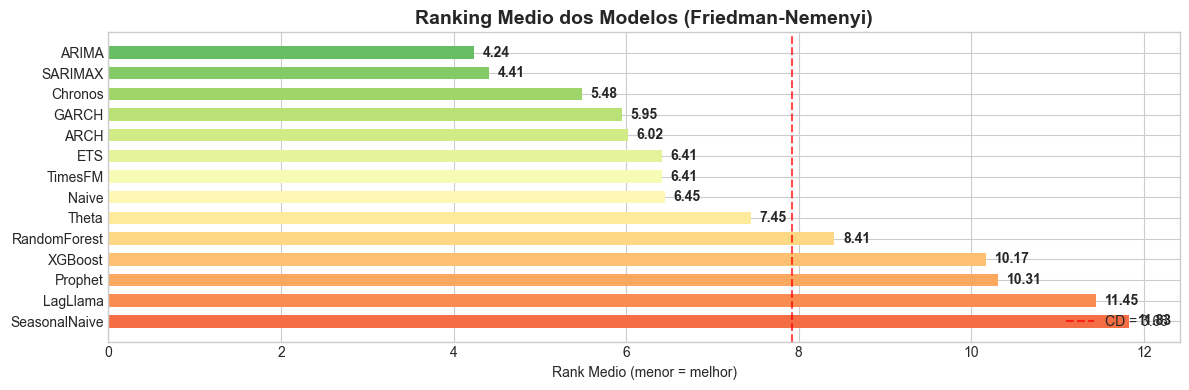

Grafico salvo: consolidado_ranking_friedman.png


In [41]:
# Diagrama de Diferença Crítica: visualiza os ranks médios dos modelos
# com a linha de CD indicando o limiar de significância estatística.
fig, ax = plt.subplots(figsize=(12, 4))

y_positions = np.arange(len(mean_ranks))
colors_rank = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(mean_ranks)))

ax.barh(y_positions, mean_ranks.values, color=colors_rank, height=0.6)

for y, (modelo, rank) in zip(y_positions, mean_ranks.items()):
    ax.text(rank + 0.1, y, f'{rank:.2f}', va='center', fontsize=10, fontweight='bold')

# Linha de diferença crítica a partir do melhor modelo
ax.axvline(x=mean_ranks.values[0] + CD, color='red', linestyle='--', alpha=0.7, 
           label=f'CD = {CD:.2f}')

ax.set_yticks(y_positions)
ax.set_yticklabels(mean_ranks.index)
ax.set_xlabel('Rank Medio (menor = melhor)')
ax.set_title('Ranking Medio dos Modelos (Friedman-Nemenyi)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('consolidado_ranking_friedman.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo: consolidado_ranking_friedman.png")

## 6b. Teste de Diebold-Mariano (DM)

O **Teste de Diebold-Mariano** (1995) compara diretamente a acurácia preditiva de dois modelos usando os erros de previsão reais (não ranks).  
Complementa o Friedman/Nemenyi: enquanto Nemenyi trabalha com ranks (ordinal), o DM usa a magnitude dos erros (intervalar).

- **H0**: os dois modelos têm a mesma acurácia preditiva  
- **H1**: um modelo é significativamente melhor que o outro  
- **Loss function**: erro quadrático (MSE)  
- **Correção**: Newey-West para autocorrelação (h=3 passos à frente)  
- **Agregação**: erros pooled sobre todas as séries e janelas walk-forward

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# Teste de Diebold-Mariano (1995):
# Compara pares de modelos usando os erros de previsão reais.
# Usa loss quadrática (MSE) com correção Newey-West para h-step ahead.
# Referência: Diebold, F. X., & Mariano, R. S. (1995).
#   "Comparing Predictive Accuracy." JBES, 13(3), 253-263.
# ──────────────────────────────────────────────────────────────────────
from scipy.stats import t as t_dist
import itertools

def diebold_mariano_test(e1, e2, h=3):
    """
    Teste de Diebold-Mariano bilateral.
    e1, e2: vetores de erros de previsão (actual - predicted).
    h: horizonte de previsão (para correção de autocorrelação Newey-West).
    Retorna (DM_stat, p_valor).
    """
    d = e1**2 - e2**2  # loss differential (MSE-based)
    n = len(d)
    if n < 5:
        return np.nan, np.nan
    
    d_mean = np.mean(d)
    
    # Variância com correção Newey-West para autocorrelação até lag h-1
    gamma_0 = np.var(d, ddof=1)
    gamma_sum = 0
    for lag in range(1, h):
        if n > lag:
            gamma_k = np.cov(d[lag:], d[:-lag])[0, 1]
            gamma_sum += gamma_k
    
    var_d = (gamma_0 + 2 * gamma_sum) / n
    
    if var_d <= 0:
        return np.nan, np.nan
    
    dm_stat = d_mean / np.sqrt(var_d)
    p_value = 2 * t_dist.sf(abs(dm_stat), df=n - 1)
    
    return dm_stat, p_value

# ── Carregar previsões e valores reais ──
df_base = pd.read_csv('base_economica_brasil.csv')
df_base['Data'] = df_base['Unnamed: 0']

PREVISOES_FILES = {
    'Naive': 'previsoes_naive.csv',
    'SeasonalNaive': 'previsoes_snaive.csv',
    'ARIMA': 'previsoes_arima.csv',
    'ARCH': 'previsoes_arch.csv',
    'Chronos': 'previsoes_chronos.csv',
    'ETS': 'previsoes_ets.csv',
    'GARCH': 'previsoes_garch.csv',
    'LagLlama': 'previsoes_lagllama.csv',
    'Prophet': 'previsoes_prophet.csv',
    'RandomForest': 'previsoes_randomforest.csv',
    'SARIMAX': 'previsoes_sarimax.csv',
    'Theta': 'previsoes_theta.csv',
    'TimesFM': 'previsoes_timesfm.csv',
    'XGBoost': 'previsoes_xgboost.csv',
}

# Carregar previsões disponíveis
col_map = {'Série': 'Serie', 'Previsão': 'Previsao'}
all_prev = {}
for model_name, fname in PREVISOES_FILES.items():
    if os.path.exists(fname):
        df_p = pd.read_csv(fname).rename(columns=col_map)
        all_prev[model_name] = df_p

print("="*70)
print("TESTE DE DIEBOLD-MARIANO")
print("="*70)
print(f"Modelos com previsões: {len(all_prev)}/{len(PREVISOES_FILES)}")
for m in sorted(all_prev):
    print(f"   OK  {m:14} : {len(all_prev[m])} previsoes")

# ── Calcular erros de previsão por (serie, data) ──
# Criar lookup de valores reais: {(serie, data): valor}
series_cols = [c for c in df_base.columns if c not in ['Unnamed: 0', 'Data']]
actuals = {}
for serie in series_cols:
    for idx, row in df_base.iterrows():
        if pd.notna(row[serie]):
            actuals[(serie, row['Data'])] = row[serie]

# Para cada modelo, calcular erros alinhados
model_errors = {}
for model_name, df_p in all_prev.items():
    errors = {}
    for _, row in df_p.iterrows():
        key = (row['Serie'], row['Data'])
        if key in actuals:
            errors[key] = actuals[key] - row['Previsao']
    model_errors[model_name] = errors

# ── Teste DM para todos os pares ──
models_list = sorted(all_prev.keys())
dm_results = []

for m1, m2 in itertools.combinations(models_list, 2):
    # Encontrar pontos em comum
    common_keys = sorted(set(model_errors[m1].keys()) & set(model_errors[m2].keys()))
    
    if len(common_keys) < 10:
        continue
    
    e1 = np.array([model_errors[m1][k] for k in common_keys])
    e2 = np.array([model_errors[m2][k] for k in common_keys])
    
    dm_stat, p_val = diebold_mariano_test(e1, e2, h=3)
    
    if not np.isnan(dm_stat):
        # Determinar qual modelo é melhor (menor MSE)
        mse1 = np.mean(e1**2)
        mse2 = np.mean(e2**2)
        melhor = m1 if mse1 < mse2 else m2
        
        dm_results.append({
            'Modelo_1': m1, 'Modelo_2': m2,
            'DM_stat': dm_stat, 'p_valor': p_val,
            'N_obs': len(common_keys),
            'MSE_1': mse1, 'MSE_2': mse2,
            'Melhor': melhor,
            'Significativo': p_val < 0.05
        })

df_dm = pd.DataFrame(dm_results)

if df_dm.empty:
    print("\n⚠️  Nenhum par com observações suficientes para o teste DM.")
    print("   Verifique se os arquivos de previsões têm a coluna 'Data' alinhada com base_economica_brasil.csv")
    df_dm = pd.DataFrame(columns=['Modelo_1', 'Modelo_2', 'DM_stat', 'p_valor',
                                   'N_obs', 'MSE_1', 'MSE_2', 'Melhor', 'Significativo'])
    df_dm.to_csv('consolidado_dm_pairwise.csv', index=False)
else:
    n_sig = df_dm['Significativo'].sum()
    n_total = len(df_dm)

    print(f"\nPares testados: {n_total}")
    print(f"Pares significativos (alpha=0.05): {n_sig} ({100*n_sig/n_total:.1f}%)")
    print(f"\nComparações significativas:")
    print("-"*70)
    for _, row in df_dm[df_dm['Significativo']].sort_values('p_valor').iterrows():
        arrow = "<" if row['MSE_1'] < row['MSE_2'] else ">"
        print(f"   {row['Modelo_1']:14} {arrow} {row['Modelo_2']:14}  "
              f"DM={row['DM_stat']:+.3f}  p={row['p_valor']:.4f}  "
              f"(melhor: {row['Melhor']})")

    print(f"\nComparações NÃO significativas: {n_total - n_sig}")
    for _, row in df_dm[~df_dm['Significativo']].sort_values('p_valor').iterrows():
        print(f"   {row['Modelo_1']:14} vs {row['Modelo_2']:14}  "
              f"DM={row['DM_stat']:+.3f}  p={row['p_valor']:.4f}")

    # Salvar resultados
    df_dm.to_csv('consolidado_dm_pairwise.csv', index=False)
    print(f"\nSalvo: consolidado_dm_pairwise.csv")


TESTE DE DIEBOLD-MARIANO
Modelos com previsões: 14/14
   OK  ARCH           : 696 previsoes
   OK  ARIMA          : 696 previsoes
   OK  Chronos        : 696 previsoes
   OK  ETS            : 696 previsoes
   OK  GARCH          : 696 previsoes
   OK  LagLlama       : 696 previsoes
   OK  Naive          : 696 previsoes
   OK  Prophet        : 696 previsoes
   OK  RandomForest   : 87 previsoes
   OK  SARIMAX        : 696 previsoes
   OK  SeasonalNaive  : 696 previsoes
   OK  Theta          : 696 previsoes
   OK  TimesFM        : 696 previsoes
   OK  XGBoost        : 696 previsoes

Pares testados: 78
Pares significativos (alpha=0.05): 38 (48.7%)

Comparações significativas:
----------------------------------------------------------------------
   LagLlama       > SeasonalNaive   DM=+2.614  p=0.0091  (melhor: SeasonalNaive)
   Naive          > Prophet         DM=+2.392  p=0.0170  (melhor: Prophet)
   Prophet        < XGBoost         DM=-2.373  p=0.0179  (melhor: Prophet)
   LagLlama       

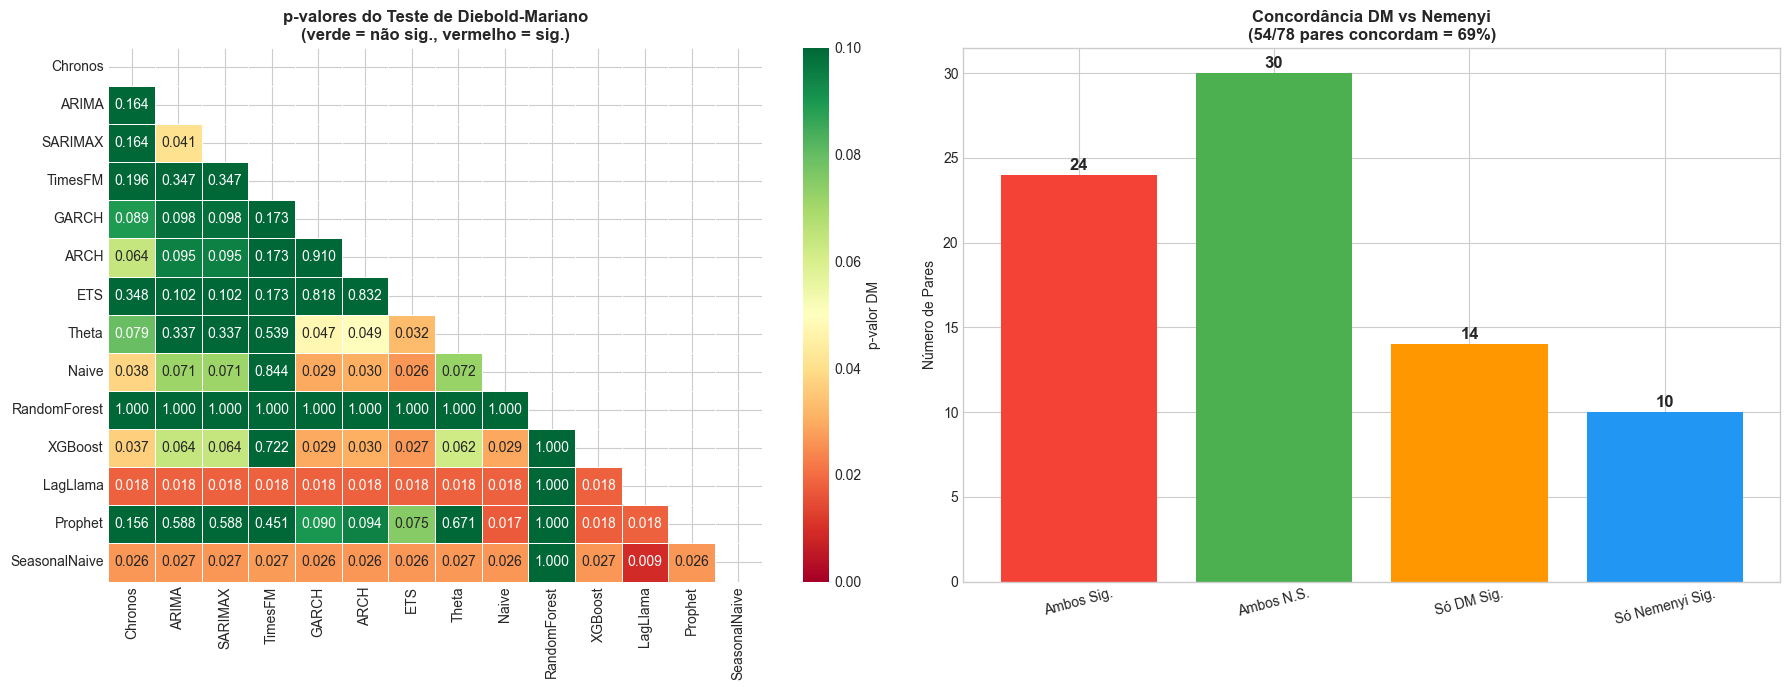

Grafico salvo: consolidado_dm_heatmap.png

Concordância DM vs Nemenyi: 54/78 pares (69%)

Discordâncias (24 pares):
   ARCH           vs Naive           DM=Sig.  Nemenyi=N.S.
   ARCH           vs Prophet         DM=N.S.  Nemenyi=Sig.
   ARCH           vs Theta           DM=Sig.  Nemenyi=N.S.
   ARIMA          vs Prophet         DM=N.S.  Nemenyi=Sig.
   ARIMA          vs SARIMAX         DM=Sig.  Nemenyi=N.S.
   ARIMA          vs XGBoost         DM=N.S.  Nemenyi=Sig.
   Chronos        vs Naive           DM=Sig.  Nemenyi=N.S.
   Chronos        vs Prophet         DM=N.S.  Nemenyi=Sig.
   ETS            vs Naive           DM=Sig.  Nemenyi=N.S.
   ETS            vs Prophet         DM=N.S.  Nemenyi=Sig.
   ETS            vs Theta           DM=Sig.  Nemenyi=N.S.
   GARCH          vs Naive           DM=Sig.  Nemenyi=N.S.
   GARCH          vs Prophet         DM=N.S.  Nemenyi=Sig.
   GARCH          vs Theta           DM=Sig.  Nemenyi=N.S.
   LagLlama       vs Prophet         DM=Sig.  Nemenyi=N.S.

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# Heatmap de p-valores DM + Comparação DM vs Nemenyi
# ──────────────────────────────────────────────────────────────────────

if df_dm.empty or len(models_list) == 0:
    print("⚠️  df_dm vazio — sem pares suficientes para heatmap DM vs Nemenyi.")
    df_conc = pd.DataFrame(columns=['Modelo_1', 'Modelo_2', 'DM_sig', 'Nemenyi_sig', 'Concordam'])
else:
    # Construir matriz simétrica de p-valores
    dm_matrix = pd.DataFrame(np.ones((len(models_list), len(models_list))),
                             index=models_list, columns=models_list)
    for _, row in df_dm.iterrows():
        dm_matrix.loc[row['Modelo_1'], row['Modelo_2']] = row['p_valor']
        dm_matrix.loc[row['Modelo_2'], row['Modelo_1']] = row['p_valor']

    # Ordenar pela mesma ordem do ranking MAPE
    mape_ranking = df_consolidated.groupby('Modelo')['MAPE'].mean().sort_values()
    dm_order = [m for m in mape_ranking.index if m in models_list]
    dm_matrix = dm_matrix.loc[dm_order, dm_order]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Heatmap de p-valores
    mask = np.triu(np.ones_like(dm_matrix, dtype=bool))
    sns.heatmap(dm_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
                mask=mask, linewidths=0.5, ax=axes[0],
                vmin=0, vmax=0.1,
                cbar_kws={'label': 'p-valor DM'})
    axes[0].set_title('p-valores do Teste de Diebold-Mariano\n(verde = não sig., vermelho = sig.)',
                       fontweight='bold')

    # Comparação: concordância DM vs Nemenyi
    concordancia = []
    for _, row_dm in df_dm.iterrows():
        m1, m2 = row_dm['Modelo_1'], row_dm['Modelo_2']
        dm_sig = row_dm['Significativo']

        # Buscar no Nemenyi
        nem_row = df_nemenyi[
            ((df_nemenyi['Modelo_1'] == m1) & (df_nemenyi['Modelo_2'] == m2)) |
            ((df_nemenyi['Modelo_1'] == m2) & (df_nemenyi['Modelo_2'] == m1))
        ]
        if len(nem_row) > 0:
            nem_sig = nem_row.iloc[0]['Significativo']
            concordancia.append({
                'Modelo_1': m1, 'Modelo_2': m2,
                'DM_sig': dm_sig, 'Nemenyi_sig': nem_sig,
                'Concordam': dm_sig == nem_sig
            })

    df_conc = pd.DataFrame(concordancia)

    if df_conc.empty:
        print("⚠️  Nenhum par com resultados tanto em DM quanto em Nemenyi para comparar concordância.")
        axes[1].set_title('Concordância DM vs Nemenyi\n(sem dados)', fontweight='bold')
    else:
        n_concordam = df_conc['Concordam'].sum()
        n_pares = len(df_conc)
        taxa = 100 * n_concordam / n_pares if n_pares > 0 else 0

        categorias = ['Ambos Sig.', 'Ambos N.S.', 'Só DM Sig.', 'Só Nemenyi Sig.']
        contagens = [
            ((df_conc['DM_sig']) & (df_conc['Nemenyi_sig'])).sum(),
            ((~df_conc['DM_sig']) & (~df_conc['Nemenyi_sig'])).sum(),
            ((df_conc['DM_sig']) & (~df_conc['Nemenyi_sig'])).sum(),
            ((~df_conc['DM_sig']) & (df_conc['Nemenyi_sig'])).sum(),
        ]
        cores = ['#F44336', '#4CAF50', '#FF9800', '#2196F3']

        bars = axes[1].bar(categorias, contagens, color=cores)
        for bar, val in zip(bars, contagens):
            if val > 0:
                axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height() + 0.3,
                             str(val), ha='center', fontweight='bold', fontsize=12)
        axes[1].set_ylabel('Número de Pares')
        axes[1].set_title(f'Concordância DM vs Nemenyi\n({n_concordam}/{n_pares} pares concordam = {taxa:.0f}%)',
                           fontweight='bold')
        axes[1].tick_params(axis='x', rotation=15)

        print(f"\nConcordância DM vs Nemenyi: {n_concordam}/{n_pares} pares ({taxa:.0f}%)")

        disc = df_conc[~df_conc['Concordam']]
        if len(disc) > 0:
            print(f"\nDiscordâncias ({len(disc)} pares):")
            for _, row in disc.iterrows():
                dm_tag = "Sig." if row['DM_sig'] else "N.S."
                nem_tag = "Sig." if row['Nemenyi_sig'] else "N.S."
                print(f"   {row['Modelo_1']:14} vs {row['Modelo_2']:14}  DM={dm_tag}  Nemenyi={nem_tag}")
        else:
            print("\nNenhuma discordância — os dois testes concordam em todos os pares.")

    plt.tight_layout()
    plt.savefig('consolidado_dm_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Grafico salvo: consolidado_dm_heatmap.png")


## 7. Tabela Formal de Vitórias por Modelo

TABELA FORMAL DE VITORIAS POR MODELO
(Baseado em 29 series)

               1o Lugar  2o Lugar  3o Lugar  Top 3  Ultimo  Rank Medio
ARIMA                 5         4         5     14       0        4.24
SARIMAX               3         7         0     11       0        4.41
Chronos               5         2         1      8       0        5.48
GARCH                 0         0         3      8       1        5.95
ARCH                  1         1         1      8       0        6.02
ETS                   3         2         2      7       0        6.41
TimesFM               3         4         1      8       0        6.41
Naive                 3         0         2      6       1        6.45
Theta                 1         0         4      5       0        7.45
RandomForest          1         2         1      4       0        8.41
XGBoost               0         0         1      1       2       10.17
Prophet               2         0         0      2       8       10.31
LagLlama        

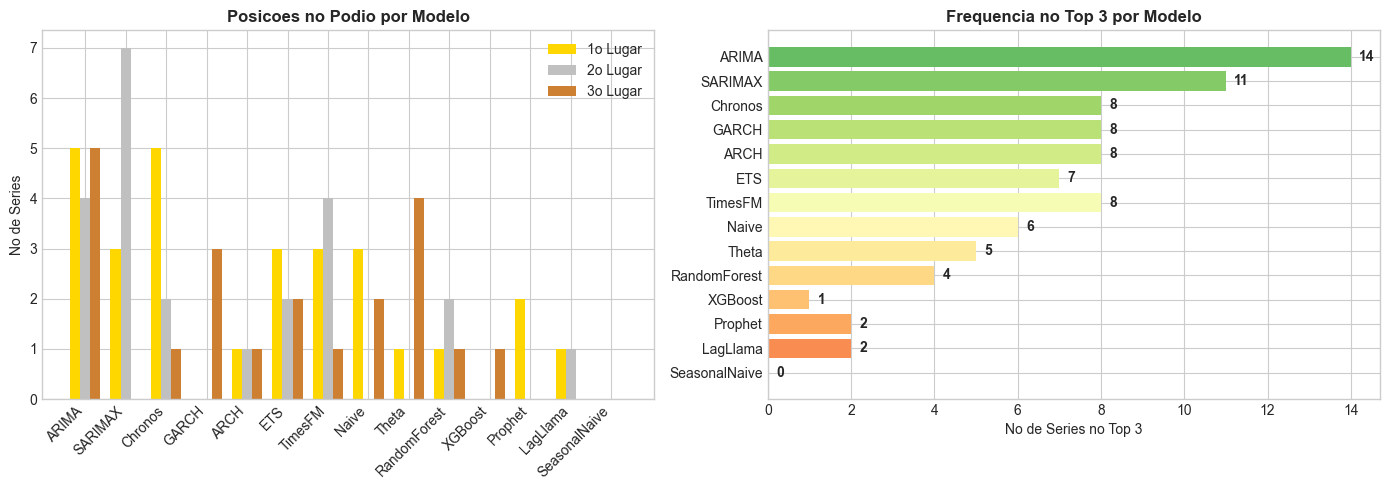

Grafico salvo: consolidado_vitorias_formal.png


In [44]:
# ──────────────────────────────────────────────────────────────────────
# Tabela formal de vitórias: para cada série, ranqueia os modelos e
# conta quantas vezes cada modelo ficou em 1º, 2º, 3º, Top 3, e último.
# ──────────────────────────────────────────────────────────────────────
ranks_per_serie = df_consolidated.pivot_table(values='MAPE', index='Serie', columns='Modelo').rank(axis=1)

wins_table = pd.DataFrame(index=df_consolidated['Modelo'].unique())
wins_table['1o Lugar'] = (ranks_per_serie == 1).sum()
wins_table['2o Lugar'] = (ranks_per_serie == 2).sum()
wins_table['3o Lugar'] = (ranks_per_serie == 3).sum()
wins_table['Top 3'] = (ranks_per_serie <= 3).sum()
wins_table['Ultimo'] = (ranks_per_serie == ranks_per_serie.max(axis=1).values[:, None]).sum()
wins_table['Rank Medio'] = ranks_per_serie.mean().round(2)
wins_table = wins_table.sort_values('Rank Medio')

print("="*70)
print("TABELA FORMAL DE VITORIAS POR MODELO")
print("="*70)
print(f"(Baseado em {len(ranks_per_serie)} series)\n")
print(wins_table.to_string())

# Visualização: pódio e top 3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = wins_table.index
x = np.arange(len(order))
w = 0.25

axes[0].bar(x - w, wins_table.loc[order, '1o Lugar'], w, label='1o Lugar', color='gold')
axes[0].bar(x, wins_table.loc[order, '2o Lugar'], w, label='2o Lugar', color='silver')
axes[0].bar(x + w, wins_table.loc[order, '3o Lugar'], w, label='3o Lugar', color='#CD7F32')
axes[0].set_xticks(x)
axes[0].set_xticklabels(order, rotation=45, ha='right')
axes[0].set_ylabel('No de Series')
axes[0].set_title('Posicoes no Podio por Modelo', fontweight='bold')
axes[0].legend()

colors_top3 = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(order)))
axes[1].barh(order, wins_table.loc[order, 'Top 3'], color=colors_top3)
for i, v in enumerate(wins_table.loc[order, 'Top 3']):
    axes[1].text(v + 0.2, i, str(int(v)), va='center', fontweight='bold')
axes[1].set_xlabel('No de Series no Top 3')
axes[1].set_title('Frequencia no Top 3 por Modelo', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('consolidado_vitorias_formal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo: consolidado_vitorias_formal.png")

## 8. Comparação por Classe Metodológica

| Classe | Modelos |
|--------|---------|
| Baseline (Benchmarks) | Naive (Random Walk), Seasonal Naive |
| Estatísticos | ARIMA, SARIMAX, ETS, Prophet, Theta |
| Machine Learning | XGBoost, RandomForest |
| Foundation Models (Pré-treinados) | Chronos, Lag-Llama, TimesFM |
| Volatilidade | ARCH, GARCH |

RESUMO POR CLASSE METODOLOGICA

  Volatilidade (2 modelos):
     MAPE: media=6.15%  mediana=4.08%  std=8.05  [min=0.17%, max=44.88%]
     MAE:  media=2162448.9571  mediana=4.0577
     RMSE: media=3005519.5531  mediana=6.3573

  Estatístico (5 modelos):
     MAPE: media=7.12%  mediana=3.69%  std=11.10  [min=0.16%, max=76.87%]
     MAE:  media=4468784.7313  mediana=2.6780
     RMSE: media=5278404.8294  mediana=3.3053

  Foundation Model (3 modelos):
     MAPE: media=7.29%  mediana=5.38%  std=7.78  [min=0.34%, max=41.88%]
     MAE:  media=25301033.3563  mediana=3.7773
     RMSE: media=27513315.5007  mediana=5.3029

  Machine Learning (2 modelos):
     MAPE: media=7.33%  mediana=4.90%  std=8.60  [min=0.50%, max=47.64%]
     MAE:  media=12220314.4975  mediana=3.4065
     RMSE: media=13315937.7466  mediana=4.0072

  Baseline (2 modelos):
     MAPE: media=9.35%  mediana=5.66%  std=10.94  [min=0.44%, max=60.91%]
     MAE:  media=27639182.4116  mediana=3.7928
     RMSE: media=28434822.4268  med

C:\Users\phill\AppData\Local\Temp\ipykernel_24956\368253681.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_consolidated, x='Classe', y='MAPE', order=class_order,


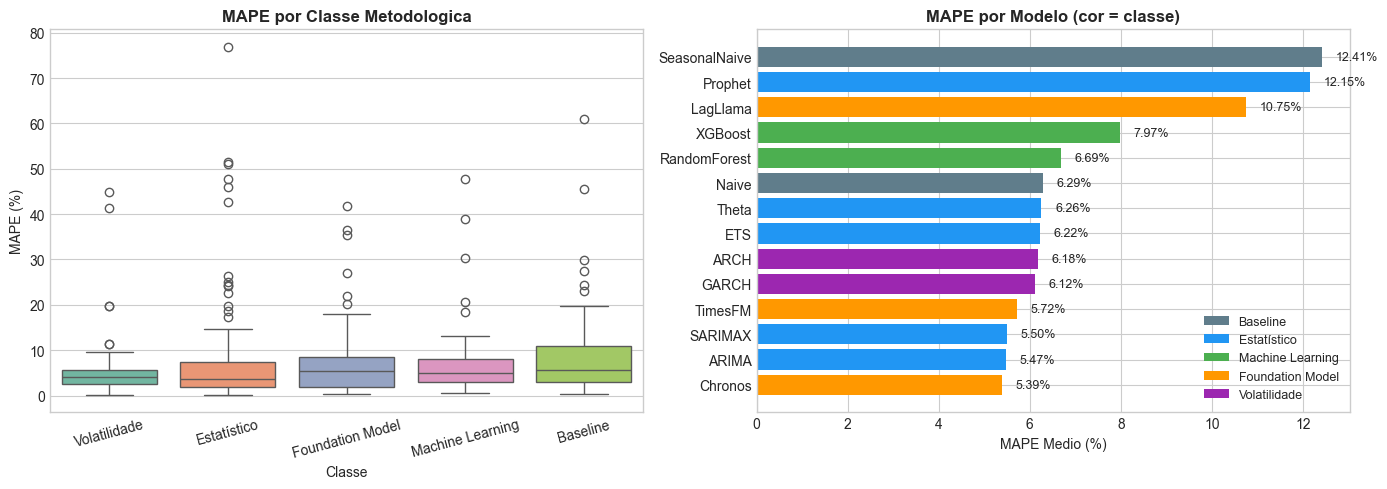

Grafico salvo: consolidado_classes_metodologicas.png


In [45]:
# ──────────────────────────────────────────────────────────────────────
# Mapeamento de classes metodológicas:
#   - Baseline: benchmarks naive (referência obrigatória)
#   - Estatístico: modelos clássicos de séries temporais
#   - Machine Learning: modelos baseados em aprendizado supervisionado
#   - Foundation Model: modelos pré-treinados em larga escala (zero-shot)
#   - Volatilidade: modelos de variância condicional (ARCH/GARCH)
# ──────────────────────────────────────────────────────────────────────
CLASS_MAP = {
    'Naive': 'Baseline',
    'SeasonalNaive': 'Baseline',
    'ARIMA': 'Estatístico',
    'SARIMAX': 'Estatístico',
    'ETS': 'Estatístico',
    'Prophet': 'Estatístico',
    'Theta': 'Estatístico',
    'XGBoost': 'Machine Learning',
    'RandomForest': 'Machine Learning',
    'Chronos': 'Foundation Model',
    'LagLlama': 'Foundation Model',
    'TimesFM': 'Foundation Model',
    'ARCH': 'Volatilidade',
    'GARCH': 'Volatilidade',
}

df_consolidated['Classe'] = df_consolidated['Modelo'].map(CLASS_MAP)

# Resumo por classe
class_summary = df_consolidated.groupby('Classe').agg({
    'MAPE': ['mean', 'median', 'std', 'min', 'max'],
    'MAE': ['mean', 'median'],
    'RMSE': ['mean', 'median']
}).round(4)
class_summary.columns = ['_'.join(col) for col in class_summary.columns]
class_summary = class_summary.sort_values('MAPE_mean')

print("="*70)
print("RESUMO POR CLASSE METODOLOGICA")
print("="*70)
for classe in class_summary.index:
    row = class_summary.loc[classe]
    n_modelos = df_consolidated[df_consolidated['Classe'] == classe]['Modelo'].nunique()
    print(f"\n  {classe} ({n_modelos} modelos):")
    print(f"     MAPE: media={row['MAPE_mean']:.2f}%  mediana={row['MAPE_median']:.2f}%  "
          f"std={row['MAPE_std']:.2f}  [min={row['MAPE_min']:.2f}%, max={row['MAPE_max']:.2f}%]")
    print(f"     MAE:  media={row['MAE_mean']:.4f}  mediana={row['MAE_median']:.4f}")
    print(f"     RMSE: media={row['RMSE_mean']:.4f}  mediana={row['RMSE_median']:.4f}")

# Melhor modelo por série e classe vencedora
df_best = df_consolidated.loc[df_consolidated.groupby('Serie')['MAPE'].idxmin()]
df_best_class = df_best.copy()
class_wins = df_best_class['Classe'].value_counts()

print(f"\nVITORIAS POR CLASSE:")
for classe, count in class_wins.items():
    bar = "█" * count
    print(f"   {classe:20} : {count:2} series  {bar}")

# Boxplot por classe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_order = class_summary.index.tolist()

# MAPE por classe
sns.boxplot(data=df_consolidated, x='Classe', y='MAPE', order=class_order,
            palette='Set2', ax=axes[0])
axes[0].set_title('MAPE por Classe Metodologica', fontweight='bold')
axes[0].set_ylabel('MAPE (%)')
axes[0].tick_params(axis='x', rotation=15)

# MAPE médio por modelo, colorido por classe
ranking_class = df_consolidated.groupby(['Modelo', 'Classe'])['MAPE'].mean().reset_index()
ranking_class = ranking_class.sort_values('MAPE')
class_colors = {
    'Baseline': '#607D8B',
    'Estatístico': '#2196F3',
    'Machine Learning': '#4CAF50',
    'Foundation Model': '#FF9800',
    'Volatilidade': '#9C27B0',
}
bar_colors = [class_colors.get(c, '#999') for c in ranking_class['Classe']]

axes[1].barh(ranking_class['Modelo'], ranking_class['MAPE'], color=bar_colors)
for i, (_, row) in enumerate(ranking_class.iterrows()):
    axes[1].text(row['MAPE'] + 0.3, i, f"{row['MAPE']:.2f}%", va='center', fontsize=9)

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in class_colors.items()]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=9)
axes[1].set_xlabel('MAPE Medio (%)')
axes[1].set_title('MAPE por Modelo (cor = classe)', fontweight='bold')

plt.tight_layout()
plt.savefig('consolidado_classes_metodologicas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo: consolidado_classes_metodologicas.png")

## 9. Robustez por Métrica (MAPE, MAE, RMSE)

ROBUSTEZ POR METRICA - A ordem dos modelos se mantem?

Rank medio por modelo (por serie) em cada metrica:
------------------------------------------------------------
               Rank_MAPE  Rank_MAE  Rank_RMSE  Rank_Medio
Modelo                                                   
ARIMA              4.241     4.017      4.069       4.109
SARIMAX            4.414     4.466      4.621       4.500
Chronos            5.483     5.724      6.172       5.793
GARCH              5.948     6.052      6.345       6.115
ARCH               6.017     6.138      6.586       6.247
ETS                6.414     6.345      6.552       6.437
Naive              6.448     6.328      6.690       6.489
TimesFM            6.414     6.517      6.552       6.494
Theta              7.448     7.414      7.138       7.333
RandomForest       8.414     8.586      6.931       7.977
XGBoost           10.172    10.103      9.828      10.034
Prophet           10.310    10.276     10.379      10.322
LagLlama          11.

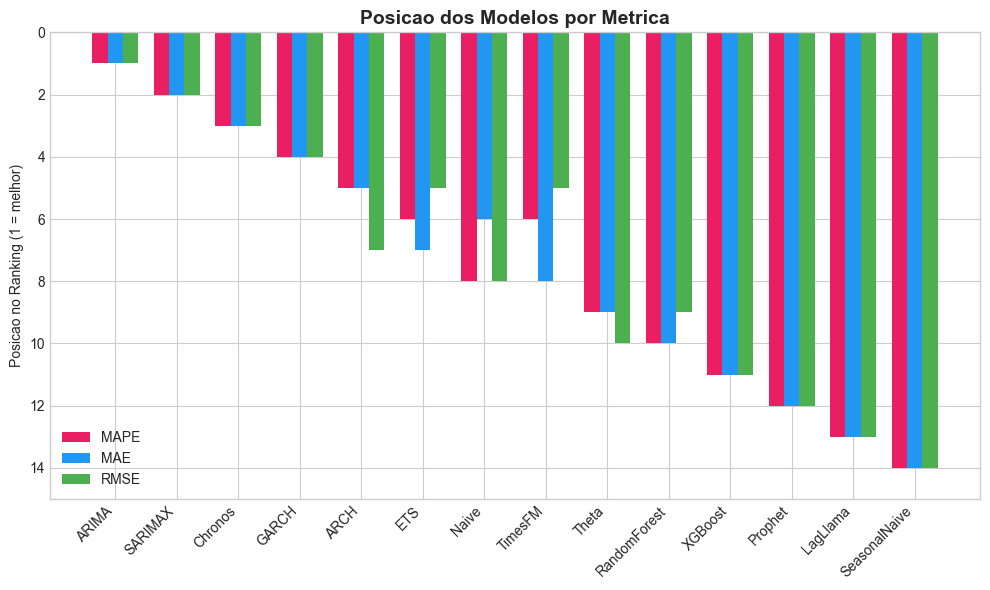

Grafico salvo: consolidado_robustez_metricas.png


In [46]:
# ──────────────────────────────────────────────────────────────────────
# Análise de robustez: verifica se a ordem dos modelos se mantém
# quando troca-se a métrica (MAPE → MAE → RMSE).
# Usa correlação de Spearman entre os rankings das diferentes métricas.
# Alta correlação indica que o ranking é robusto à escolha da métrica.
# ──────────────────────────────────────────────────────────────────────
print("="*70)
print("ROBUSTEZ POR METRICA - A ordem dos modelos se mantem?")
print("="*70)

metrics = ['MAPE', 'MAE', 'RMSE']
rankings_by_metric = {}

for metric in metrics:
    pivot_m = df_consolidated.pivot_table(values=metric, index='Serie', columns='Modelo')
    rank_m = pivot_m.rank(axis=1).mean().sort_values()
    rankings_by_metric[metric] = rank_m

# Tabela comparativa de rankings por métrica
df_robustez = pd.DataFrame({
    f'Rank_{m}': rankings_by_metric[m] for m in metrics
})
df_robustez['Rank_Medio'] = df_robustez.mean(axis=1)
df_robustez = df_robustez.sort_values('Rank_Medio')

for m in metrics:
    df_robustez[f'Pos_{m}'] = df_robustez[f'Rank_{m}'].rank().astype(int)

print("\nRank medio por modelo (por serie) em cada metrica:")
print("-"*60)
print(df_robustez[[f'Rank_{m}' for m in metrics] + ['Rank_Medio']].round(3).to_string())

# Correlação de Spearman entre rankings de métricas
from scipy.stats import spearmanr

print(f"\nCORRELACAO DE SPEARMAN ENTRE RANKINGS:")
print("-"*50)
for i in range(len(metrics)):
    for j in range(i+1, len(metrics)):
        m1, m2 = metrics[i], metrics[j]
        corr, pval = spearmanr(df_robustez[f'Rank_{m1}'], df_robustez[f'Rank_{m2}'])
        sig = "*" if pval < 0.05 else " "
        print(f"   {m1:6} vs {m2:6} : rho = {corr:.4f}  (p = {pval:.4f}) {sig}")

# Gráfico: posição por métrica
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_robustez))
width = 0.25
metric_colors = {'MAPE': '#E91E63', 'MAE': '#2196F3', 'RMSE': '#4CAF50'}

for i, m in enumerate(metrics):
    ax.bar(x + i*width, df_robustez[f'Pos_{m}'], width, label=m, color=metric_colors[m])

ax.set_xticks(x + width)
ax.set_xticklabels(df_robustez.index, rotation=45, ha='right')
ax.set_ylabel('Posicao no Ranking (1 = melhor)')
ax.set_title('Posicao dos Modelos por Metrica', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, len(df_robustez) + 1)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('consolidado_robustez_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo: consolidado_robustez_metricas.png")

## 10. Ranking Padronizado por Série

Ranking normalizado: para cada série, os modelos recebem posição 1º a Nº (onde N = número de modelos carregados).  
A média dos rankings evita que séries mais difíceis (com MAPE alto) dominem a comparação agregada.

RANKING PADRONIZADO POR SERIE (MAPE)
(1 = melhor modelo na serie, 14 = pior)

Modelo              ARCH  ARIMA  Chronos   ETS  GARCH  LagLlama  Naive  Prophet  RandomForest  SARIMAX  SeasonalNaive  Theta  TimesFM  XGBoost
Serie                                                                                                                                         
Brent_USD            4.5    6.0     11.0   9.0    4.5       8.0    3.0     14.0           2.0      7.0           13.0   12.0      1.0     10.0
CPI_USA              4.0    2.0      8.0   5.0    3.0      14.0    9.0      6.0          12.0      1.0           13.0    7.0     11.0     10.0
Cafe_USD             4.5    8.0      7.0   1.0    4.5      10.0    2.5     12.0           9.0      2.5           13.0    6.0     11.0     14.0
Cambio_USDBRL        3.5    8.0      7.0   9.0    3.5      12.0    5.5     11.0           2.0      5.5           13.0   10.0      1.0     14.0
Cobre_USD            2.5    6.0      8.0  11.0    2.5      12.0 

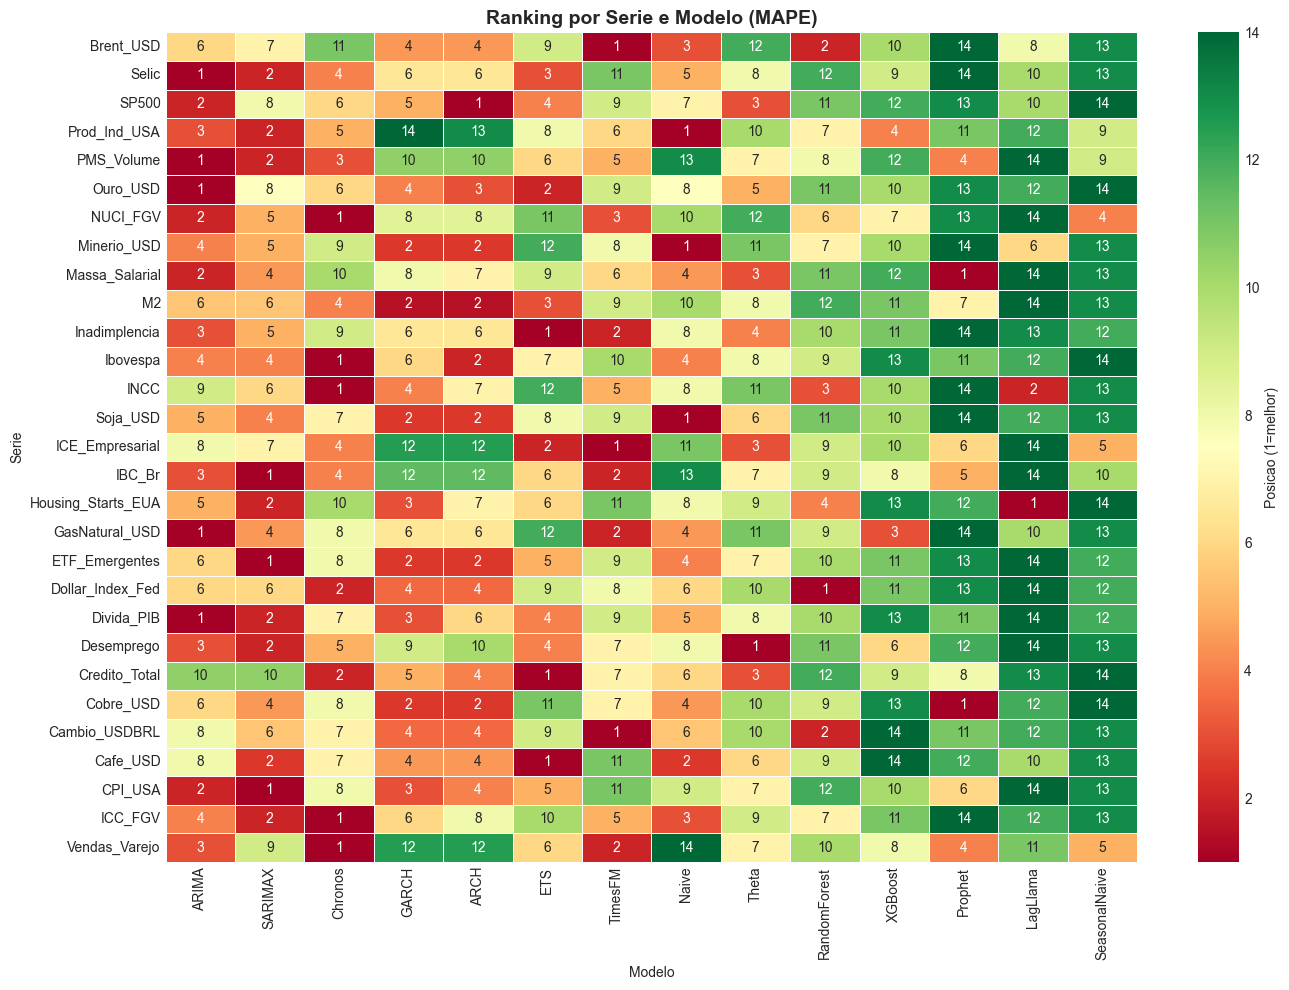

Grafico salvo: consolidado_ranking_padronizado.png


In [47]:
# ──────────────────────────────────────────────────────────────────────
# Ranking padronizado por série: para cada série, os modelos recebem
# posição 1 a N. A média dos rankings evita que séries com MAPE alto
# dominem a comparação agregada (ao contrário do MAPE médio simples).
# ──────────────────────────────────────────────────────────────────────
pivot_ranks = df_consolidated.pivot_table(values='MAPE', index='Serie', columns='Modelo').rank(axis=1)

n_modelos = len(pivot_ranks.columns)
print("="*70)
print("RANKING PADRONIZADO POR SERIE (MAPE)")
print("="*70)
print(f"(1 = melhor modelo na serie, {n_modelos} = pior)\n")

print(pivot_ranks.round(1).to_string())

# Ranking médio
mean_rank = pivot_ranks.mean().sort_values()
print(f"\nRANKING MEDIO:")
print("-"*40)
for i, (modelo, rank) in enumerate(mean_rank.items(), 1):
    medal = "1o" if i == 1 else "2o" if i == 2 else "3o" if i == 3 else "  "
    print(f"{medal} {i:2}. {modelo:15} : {rank:.3f}")

# Comparação: ranking padronizado vs MAPE médio
ranking_mape = df_consolidated.groupby('Modelo')['MAPE'].mean().sort_values()

print(f"\nCOMPARACAO: Ranking Padronizado vs MAPE Medio")
print("-"*60)
print(f"{'Modelo':15} | {'Pos. Rank Pad.':15} | {'Pos. MAPE Medio':15}")
print("-"*60)

rank_order = mean_rank.index.tolist()
mape_order = ranking_mape.index.tolist()

for modelo in rank_order:
    pos_rank = rank_order.index(modelo) + 1
    pos_mape = mape_order.index(modelo) + 1
    diff = pos_mape - pos_rank
    arrow = "^" if diff > 0 else "v" if diff < 0 else "="
    print(f"{modelo:15} | {pos_rank:^15} | {pos_mape:^15} {arrow}")

# Heatmap de ranks por série
fig, ax = plt.subplots(figsize=(14, 10))

pivot_ranks_sorted = pivot_ranks[mean_rank.index]
pivot_ranks_sorted = pivot_ranks_sorted.loc[pivot_ranks_sorted.mean(axis=1).sort_values().index]

sns.heatmap(pivot_ranks_sorted, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Posicao (1=melhor)'}, 
            vmin=1, vmax=n_modelos)

ax.set_title('Ranking por Serie e Modelo (MAPE)', fontsize=14, fontweight='bold')
ax.set_xlabel('Modelo')
ax.set_ylabel('Serie')

plt.tight_layout()
plt.savefig('consolidado_ranking_padronizado.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo: consolidado_ranking_padronizado.png")

## 11. Análise por Nível de Dificuldade da Série

Cruzamento entre a classificação de dificuldade da série (fácil, moderada, difícil) e o desempenho de cada modelo.

DESEMPENHO POR NIVEL DE DIFICULDADE DA SERIE

[FACIL] SERIES FACIL (13 series: CPI_USA, Credito_Total, Divida_PIB, Dollar_Index_Fed, IBC_Br, ICC_FGV, ICE_Empresarial, M2, Massa_Salarial, NUCI_FGV, PMS_Volume, Prod_Ind_USA, Vendas_Varejo)
--------------------------------------------------
   1o  1. Chronos         : 1.39%
   2o  2. TimesFM         : 1.55%
   3o  3. ARIMA           : 1.57%
       4. ETS             : 1.65%
       5. SARIMAX         : 1.66%
       6. Theta           : 1.78%
       7. Prophet         : 2.50%
       8. RandomForest    : 2.57%
       9. XGBoost         : 2.61%
      10. ARCH            : 2.84%
      11. Naive           : 2.88%
      12. GARCH           : 2.92%
      13. SeasonalNaive   : 4.41%
      14. LagLlama        : 8.83%

[MODERADA] SERIES MODERADA (13 series: Brent_USD, Cambio_USDBRL, Cobre_USD, Desemprego, ETF_Emergentes, Housing_Starts_EUA, Ibovespa, Inadimplencia, Minerio_USD, Ouro_USD, SP500, Selic, Soja_USD)
--------------------------------------

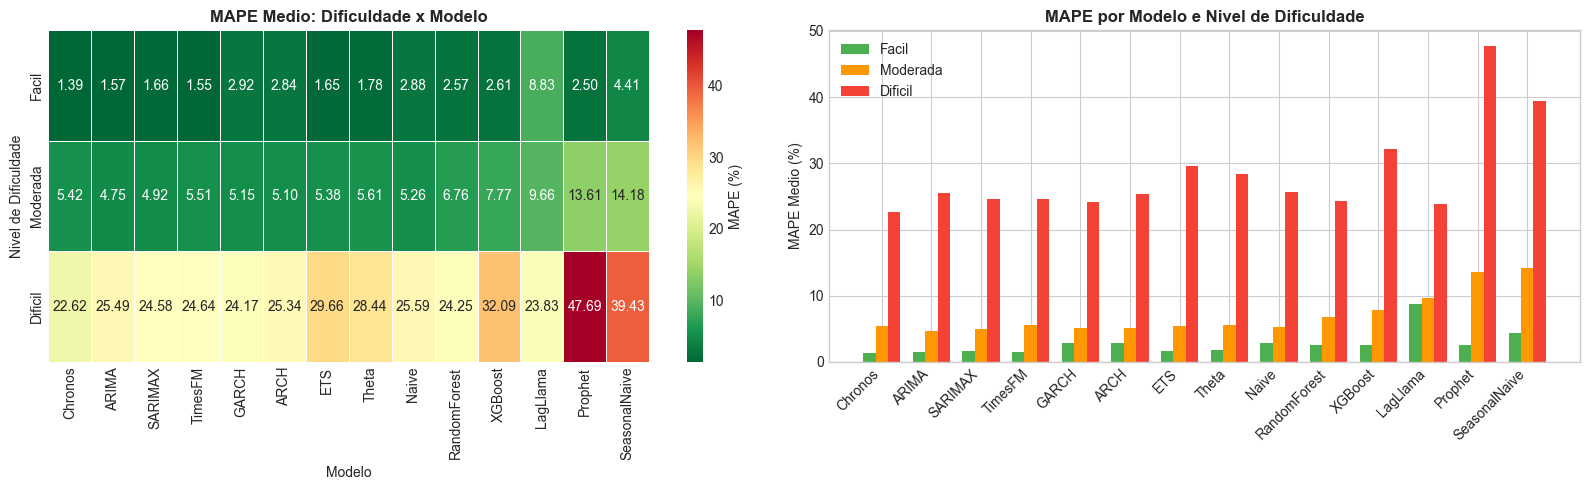

Grafico salvo: consolidado_dificuldade_modelo.png


In [48]:
# ──────────────────────────────────────────────────────────────────────
# Análise por nível de dificuldade: cruza a dificuldade da série
# (baseada no MAPE médio de todos os modelos) com o desempenho
# de cada modelo. Permite responder:
# "Qual modelo é melhor para séries fáceis/moderadas/difíceis?"
# ──────────────────────────────────────────────────────────────────────
avg_mape = df_consolidated.groupby('Serie')['MAPE'].mean()

def classify_difficulty(mape):
    if mape < 5:
        return 'Facil'
    elif mape < 15:
        return 'Moderada'
    else:
        return 'Dificil'

serie_difficulty = avg_mape.apply(classify_difficulty)
df_consolidated['Dificuldade'] = df_consolidated['Serie'].map(serie_difficulty)

print("="*70)
print("DESEMPENHO POR NIVEL DE DIFICULDADE DA SERIE")
print("="*70)

for dif in ['Facil', 'Moderada', 'Dificil']:
    df_dif = df_consolidated[df_consolidated['Dificuldade'] == dif]
    series_list = df_dif['Serie'].unique()
    
    if len(series_list) == 0:
        continue
    
    tag = "[FACIL]" if dif == "Facil" else "[MODERADA]" if dif == "Moderada" else "[DIFICIL]"
    print(f"\n{tag} SERIES {dif.upper()} ({len(series_list)} series: {', '.join(sorted(series_list))})")
    print("-"*50)
    
    ranking_dif = df_dif.groupby('Modelo')['MAPE'].mean().sort_values()
    for i, (modelo, mape) in enumerate(ranking_dif.items(), 1):
        medal = "1o" if i == 1 else "2o" if i == 2 else "3o" if i == 3 else "  "
        print(f"   {medal} {i:2}. {modelo:15} : {mape:.2f}%")

# Heatmap e barras agrupadas
pivot_dif = df_consolidated.groupby(['Dificuldade', 'Modelo'])['MAPE'].mean().unstack()
pivot_dif = pivot_dif.reindex(['Facil', 'Moderada', 'Dificil'])
model_order = df_consolidated.groupby('Modelo')['MAPE'].mean().sort_values().index
pivot_dif = pivot_dif[model_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_dif, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'MAPE (%)'})
axes[0].set_title('MAPE Medio: Dificuldade x Modelo', fontweight='bold')
axes[0].set_ylabel('Nivel de Dificuldade')

dif_levels = ['Facil', 'Moderada', 'Dificil']
dif_colors = {'Facil': '#4CAF50', 'Moderada': '#FF9800', 'Dificil': '#F44336'}
x = np.arange(len(model_order))
width = 0.25

for i, dif in enumerate(dif_levels):
    if dif in pivot_dif.index:
        axes[1].bar(x + i*width, pivot_dif.loc[dif], width, label=dif, color=dif_colors[dif])

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(model_order, rotation=45, ha='right')
axes[1].set_ylabel('MAPE Medio (%)')
axes[1].set_title('MAPE por Modelo e Nivel de Dificuldade', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('consolidado_dificuldade_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo: consolidado_dificuldade_modelo.png")

## 12. Salvar Resultados Consolidados

In [49]:
# ──────────────────────────────────────────────────────────────────────
# Exportação de todos os resultados consolidados em CSV para uso
# posterior (dissertação, tabelas LaTeX, etc.)
# ──────────────────────────────────────────────────────────────────────
df_consolidated.to_csv('consolidado_todos_resultados.csv', index=False)
print("Salvo: consolidado_todos_resultados.csv")

df_summary.to_csv('consolidado_resumo_modelos.csv')
print("Salvo: consolidado_resumo_modelos.csv")

df_best.to_csv('consolidado_melhor_modelo_serie.csv', index=False)
print("Salvo: consolidado_melhor_modelo_serie.csv")

pivot_mape.to_csv('consolidado_mape_serie_modelo.csv')
print("Salvo: consolidado_mape_serie_modelo.csv")

wins_table.to_csv('consolidado_vitorias_formal.csv')
print("Salvo: consolidado_vitorias_formal.csv")

df_nemenyi.to_csv('consolidado_nemenyi_pairwise.csv', index=False)
print("Salvo: consolidado_nemenyi_pairwise.csv")

df_dm.to_csv('consolidado_dm_pairwise.csv', index=False)
print("Salvo: consolidado_dm_pairwise.csv")

pivot_ranks.to_csv('consolidado_ranking_padronizado.csv')
print("Salvo: consolidado_ranking_padronizado.csv")

df_robustez.to_csv('consolidado_robustez_metricas.csv')
print("Salvo: consolidado_robustez_metricas.csv")

print(f"\nTotal: 9 arquivos CSV exportados")

Salvo: consolidado_todos_resultados.csv
Salvo: consolidado_resumo_modelos.csv
Salvo: consolidado_melhor_modelo_serie.csv
Salvo: consolidado_mape_serie_modelo.csv
Salvo: consolidado_vitorias_formal.csv
Salvo: consolidado_nemenyi_pairwise.csv
Salvo: consolidado_dm_pairwise.csv
Salvo: consolidado_ranking_padronizado.csv
Salvo: consolidado_robustez_metricas.csv

Total: 9 arquivos CSV exportados


## 13. Resumo Executivo

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# Resumo Executivo: síntese de todos os resultados em um único bloco.
# Inclui: ranking, vitórias, estatísticas gerais, Friedman/Nemenyi,
# Diebold-Mariano, classes metodológicas e robustez por métrica.
# ──────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("RESUMO EXECUTIVO")
print("="*70)

ranking = df_consolidated.groupby('Modelo')['MAPE'].mean().sort_values()
wins = df_best['Modelo'].value_counts()

print(f"\nMODELOS AVALIADOS: {len(ranking)}")
print(f"SERIES ANALISADAS: {df_consolidated['Serie'].nunique()}")

print(f"\nMELHOR MODELO (MAPE medio): {ranking.index[0]} ({ranking.values[0]:.2f}%)")
print(f"PIOR MODELO (MAPE medio): {ranking.index[-1]} ({ranking.values[-1]:.2f}%)")

print(f"\nMODELO COM MAIS VITORIAS: {wins.index[0]} ({wins.values[0]} series)")

print(f"\nESTATISTICAS GERAIS:")
print(f"   MAPE medio geral: {df_consolidated['MAPE'].mean():.2f}%")
print(f"   MAPE mediano geral: {df_consolidated['MAPE'].median():.2f}%")
print(f"   Melhor resultado: {df_consolidated['MAPE'].min():.2f}%")
print(f"   Pior resultado: {df_consolidated['MAPE'].max():.2f}%")

print(f"\nQUALIDADE DAS PREVISOES:")
excellent = (df_consolidated['MAPE'] < 5).sum()
good = ((df_consolidated['MAPE'] >= 5) & (df_consolidated['MAPE'] < 10)).sum()
moderate = ((df_consolidated['MAPE'] >= 10) & (df_consolidated['MAPE'] < 20)).sum()
poor = (df_consolidated['MAPE'] >= 20).sum()
total = len(df_consolidated)

print(f"   Excelente (MAPE < 5%):     {excellent:3} ({100*excellent/total:.1f}%)")
print(f"   Bom (5% <= MAPE < 10%):    {good:3} ({100*good/total:.1f}%)")
print(f"   Moderado (10% <= MAPE < 20%): {moderate:3} ({100*moderate/total:.1f}%)")
print(f"   Fraco (MAPE >= 20%):       {poor:3} ({100*poor/total:.1f}%)")

print(f"\nTESTE DE SIGNIFICANCIA (Friedman):")
print(f"   chi2 = {stat:.4f}, p-valor = {p_value:.6f}")
print(f"   Diferenca significativa: {'SIM' if p_value < 0.05 else 'NAO'} (alpha=0.05)")
print(f"   Diferenca Critica (Nemenyi): {CD:.3f}")
print(f"   Pares significativamente diferentes (Nemenyi): {df_nemenyi['Significativo'].sum()}/{len(df_nemenyi)}")

print(f"\nTESTE DE DIEBOLD-MARIANO:")
if not df_dm.empty:
    print(f"   Pares significativamente diferentes (DM): {df_dm['Significativo'].sum()}/{len(df_dm)}")
    _n_concordam = n_concordam if 'n_concordam' in vars() else 0
    _n_pares = n_pares if 'n_pares' in vars() else 0
    _taxa = taxa if 'taxa' in vars() else 0.0
    print(f"   Concordância DM vs Nemenyi: {_n_concordam}/{_n_pares} pares ({_taxa:.0f}%)")
else:
    print("   Sem resultados DM (previsões não disponíveis)")

print(f"\nRANKING PADRONIZADO (rank medio por serie):")
mean_rank_final = pivot_ranks.mean().sort_values()
for i, (m, r) in enumerate(mean_rank_final.items(), 1):
    if i <= 3:
        medal = "1o" if i == 1 else "2o" if i == 2 else "3o"
        print(f"   {medal} {m}: {r:.2f}")

print(f"\nCLASSE METODOLOGICA COM MELHOR MAPE MEDIO:")
for classe, row in class_summary.iterrows():
    print(f"   {classe:20} : {row['MAPE_mean']:.2f}%")

print(f"\nROBUSTEZ POR METRICA:")
for m1, m2 in [('MAPE','MAE'), ('MAPE','RMSE'), ('MAE','RMSE')]:
    corr, _ = spearmanr(df_robustez[f'Rank_{m1}'], df_robustez[f'Rank_{m2}'])
    print(f"   Spearman {m1} vs {m2}: rho = {corr:.3f}")

print("\n" + "="*70)
print("CONSOLIDACAO COMPLETA!")
print("="*70)



RESUMO EXECUTIVO

MODELOS AVALIADOS: 14
SERIES ANALISADAS: 29

MELHOR MODELO (MAPE medio): Chronos (5.39%)
PIOR MODELO (MAPE medio): SeasonalNaive (12.41%)

MODELO COM MAIS VITORIAS: ARIMA (5 series)

ESTATISTICAS GERAIS:
   MAPE medio geral: 7.37%
   MAPE mediano geral: 4.48%
   Melhor resultado: 0.16%
   Pior resultado: 76.87%

QUALIDADE DAS PREVISOES:
   Excelente (MAPE < 5%):     226 (55.7%)
   Bom (5% <= MAPE < 10%):    105 (25.9%)
   Moderado (10% <= MAPE < 20%):  46 (11.3%)
   Fraco (MAPE >= 20%):        29 (7.1%)

TESTE DE SIGNIFICANCIA (Friedman):
   chi2 = 137.0225, p-valor = 0.000000
   Diferenca significativa: SIM (alpha=0.05)
   Diferenca Critica (Nemenyi): 3.685
   Pares significativamente diferentes (Nemenyi): 36/91

TESTE DE DIEBOLD-MARIANO:
   Pares significativamente diferentes (DM): 38/78
   Concordância DM vs Nemenyi: 54/78 pares (69%)

RANKING PADRONIZADO (rank medio por serie):
   1o ARIMA: 4.24
   2o SARIMAX: 4.41
   3o Chronos: 5.48

CLASSE METODOLOGICA COM MEL

## Documentação do Período de Teste

Registro explícito do recorte temporal utilizado para avaliação out-of-sample, visando transparência metodológica e antecipação de questionamentos da banca sobre contexto macroeconômico.

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# Documentação do Período de Teste
# ──────────────────────────────────────────────────────────────────────
df_base = pd.read_csv('base_economica_brasil.csv', index_col=0, parse_dates=True)
TEST_SIZE = 24

total_obs = len(df_base)
periodo_inicio = df_base.index.min()
periodo_fim = df_base.index.max()
treino_fim = df_base.index[-(TEST_SIZE + 1)]
teste_inicio = df_base.index[-TEST_SIZE]
teste_fim = df_base.index[-1]

print("="*70)
print("DOCUMENTAÇÃO DO PERÍODO DE TESTE")
print("="*70)
print(f"\nBase de dados: {total_obs} observações mensais")
print(f"Período total: {periodo_inicio:%Y-%m} a {periodo_fim:%Y-%m}")
print(f"\nTreino: {periodo_inicio:%Y-%m} a {treino_fim:%Y-%m} ({total_obs - TEST_SIZE} meses)")
print(f"Teste:  {teste_inicio:%Y-%m} a {teste_fim:%Y-%m} ({TEST_SIZE} meses)")
print(f"\nProtocolo: Walk-forward com janela expansível (expanding window)")
print(f"Horizonte de previsão (h): 3 meses")
print(f"Número de janelas: {TEST_SIZE // 3} (= {TEST_SIZE} / 3)")
print(f"\nNota: O período de teste cobre {TEST_SIZE} meses contínuos que podem")
print(f"incluir eventos macroeconômicos específicos (ciclos de juros, eleições,")
print(f"choques externos). Todos os 14 modelos foram avaliados exatamente sobre")
print(f"o mesmo intervalo, garantindo comparabilidade.")
print("="*70)

## Verificação de Integridade: Treino vs. Teste

Asserção automática garantindo que nenhum modelo teve acesso a dados do período de teste durante o treinamento. Verifica ausência de sobreposição de índices temporais.

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# Verificação automática: nenhum modelo viu o conjunto de teste
# ──────────────────────────────────────────────────────────────────────
import pandas as pd

df_check = pd.read_csv('base_economica_brasil.csv', index_col=0, parse_dates=True)
TEST_SIZE_CHECK = 24
SERIES_EXCLUIDAS_CHECK = ['PIM', 'IPCA_mensal']

series_validas = [c for c in df_check.columns if c not in SERIES_EXCLUIDAS_CHECK]

print("="*70)
print("VERIFICAÇÃO DE INTEGRIDADE: TREINO vs. TESTE")
print("="*70)

n_erros = 0
n_curtas = 0
for serie in series_validas:
    s = df_check[serie].dropna()
    n_total = len(s)

    # Série curta demais para ter partição treino/teste
    if n_total <= TEST_SIZE_CHECK:
        print(f"  ⚠ {serie}: apenas {n_total} obs (≤ TEST_SIZE={TEST_SIZE_CHECK}), sem treino possível — pulando.")
        n_curtas += 1
        continue

    # Partição esperada
    train_idx = s.index[:-TEST_SIZE_CHECK]
    test_idx = s.index[-TEST_SIZE_CHECK:]

    # Verificar tamanhos
    if n_total != len(train_idx) + len(test_idx):
        print(f"  ✗ {serie}: |treino| + |teste| != |total|")
        n_erros += 1
        continue

    # Verificar que não há sobreposição
    overlap = train_idx.intersection(test_idx)
    if len(overlap) > 0:
        print(f"  ✗ {serie}: SOBREPOSIÇÃO DETECTADA em {len(overlap)} datas!")
        n_erros += 1
    else:
        # Verificar que treino termina antes do teste
        if not (train_idx.max() < test_idx.min()):
            print(f"  ✗ {serie}: treino não termina antes do teste!")
            n_erros += 1

print(f"\nSéries verificadas: {len(series_validas)}")
print(f"TEST_SIZE: {TEST_SIZE_CHECK} meses por série")
if n_curtas > 0:
    print(f"Séries curtas (puladas): {n_curtas}")

if n_erros == 0:
    print(f"\n✅ Sem sobreposição entre treino e teste em nenhuma série.")
    print(f"   Todas as {len(series_validas) - n_curtas} séries válidas passaram na verificação.")
else:
    print(f"\n⚠️ ATENÇÃO: {n_erros} séries com problemas de sobreposição!")

print("="*70)


## Ambiente Computacional

Versões das principais bibliotecas utilizadas nos 14 notebooks de forecasting. Documenta o ambiente de execução para fins de reprodutibilidade.

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# Ambiente Computacional — versões das bibliotecas principais
# ──────────────────────────────────────────────────────────────────────
import sys, platform

print("="*70)
print("AMBIENTE COMPUTACIONAL")
print("="*70)
print(f"Python:   {sys.version}")
print(f"Plataforma: {platform.platform()}")
print()

libs = [
    'pandas', 'numpy', 'sklearn', 'statsmodels', 'xgboost',
    'arch', 'prophet', 'pmdarima', 'torch', 'transformers',
    'chronos', 'gluonts', 'timesfm',
]

for lib_name in libs:
    try:
        mod = __import__(lib_name)
        ver = getattr(mod, '__version__', 'versão não disponível')
        display_name = mod.__name__ if hasattr(mod, '__name__') else lib_name
        print(f"  {display_name:20} {ver}")
    except ImportError:
        print(f"  {lib_name:20} NÃO INSTALADO")

# Bibliotecas que requerem import especial
special = {
    'lag_llama': 'lag_llama',
    'tempo': 'tempo',
}
for display, import_name in special.items():
    try:
        mod = __import__(import_name)
        ver = getattr(mod, '__version__', 'instalado (sem __version__)')
        print(f"  {display:20} {ver}")
    except ImportError:
        print(f"  {display:20} NÃO INSTALADO")

print()
print("="*70)